# <font color="steelblue">Detección de anomalías con Isolation Forest</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 05/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.



In [ ]:
#@title Configuración del cuaderno
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs, load_wine
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

RNG = 42

# <font color="steelblue">1. Introducción a la detección de anomalías</font>

Una **anomalía** (o *outlier*) es una observación que se desvía tanto del resto que despierta la sospecha de haber sido generada por un mecanismo distinto. Detectarlas es clave en multitud de campos: **fraude** con tarjetas, **intrusiones** en redes, **fallos** en maquinaria, **errores** de medida o diagnósticos médicos atípicos.

Conviene distinguir dos situaciones:

* **Detección de *outliers*** (no supervisada): el conjunto de entrenamiento **ya contiene** anomalías y queremos localizarlas. Es el caso típico de Isolation Forest.
* **Detección de novedades** (semi-supervisada): entrenamos solo con datos "normales" y queremos decidir si una observación **nueva** es atípica.

Y tres tipos de anomalía:

* **Puntual** — un valor aislado anómalo (una transacción de importe enorme).
* **Contextual** — normal en general, anómala en su contexto (35 °C es normal en verano, anómalo en enero).
* **Colectiva** — un conjunto de puntos que, juntos, son anómalos aunque por separado no lo parezcan.

**¿Por qué es difícil?** Casi siempre **no hay etiquetas** (no sabemos qué es anomalía), las anomalías son **escasísimas** (fuerte desequilibrio) y "raro" es difícil de definir. Por eso dominan los métodos **no supervisados**.

## <font color="steelblue">1.1. Una mirada geométrica</font>

Imaginemos los datos como una **nube de puntos** en un espacio de $p$ dimensiones. La intuición común a todos los métodos es que **los puntos normales se agolpan en regiones densas** (el "cuerpo" de la nube) y **las anomalías habitan las zonas vacías** de la periferia. Lo que cambia entre métodos es **cómo formalizan geométricamente** esa idea:

| Familia | Idea geométrica | Cómo decide que algo es anómalo | Ejemplos |
|---|---|---|---|
| **Estadísticos** | Contornos de probabilidad (elipses) | Fuera de la elipse de confianza | Z-score, *Elliptic Envelope* |
| **Distancia / densidad** | Radio del vecindario local | Pocos vecinos cerca / densidad local baja | kNN, **LOF** |
| **Frontera** | Superficie que envuelve lo normal | Cae fuera de la superficie aprendida | **One-Class SVM** |
| **Aislamiento** | Facilidad de "recortar" el punto | Basta cortar pocas veces para dejarlo solo | **Isolation Forest** |

Los tres primeros enfoques **modelan primero la forma de lo normal** (una elipse, una densidad, una frontera) y luego miran qué queda fuera. Isolation Forest, como veremos, **invierte** esa lógica con una idea puramente geométrica: en una región vacía, **muy pocos cortes** bastan para encerrar un punto en una "caja" que solo lo contenga a él.

# <font color="steelblue">2. Isolation Forest</font>


## <font color="steelblue">2.1. La idea central: aislar en vez de modelar</font>

**Isolation Forest** (Liu, Ting & Zhou, 2008) se apoya en dos propiedades que definen a una anomalía: son **pocas** (*few*) y **diferentes** (*different*). La consecuencia geométrica es que **están en zonas poco pobladas** del espacio y, por tanto, **son fáciles de separar** del resto.

Si vamos partiendo el espacio con cortes aleatorios, una anomalía —rodeada de vacío— queda aislada con **muy pocos cortes**; un punto normal —rodeado de muchos vecinos parecidos en una región densa— necesita **muchos** para quedar solo. Esa **"facilidad de aislamiento"** es directamente la señal de anomalía. No hace falta modelar densidades ni fronteras: basta contar cortes.

## <font color="steelblue">2.2. Árboles de aislamiento (iTrees)</font>

Un **árbol de aislamiento** (*isolation tree* o iTree) materializa esa idea mediante una **partición recursiva aleatoria** del espacio. En cada nodo:

1. se elige **una variable $q$ al azar**;
2. se elige un **punto de corte $p$ al azar**, uniforme entre el mínimo y el máximo de $q$ en ese nodo;
3. los datos se reparten en dos hijos: $\{x : x_q < p\}$ y $\{x : x_q \ge p\}$.

El proceso se repite hasta que cada punto queda **aislado** en su propia hoja, o hasta alcanzar una **altura límite** $l = \lceil \log_2 \psi
ceil$ (la altura media de un árbol con $\psi$ puntos). El límite es deliberado: solo nos interesa **cuándo se aíslan los puntos cercanos a la raíz** (las anomalías); para los puntos normales basta saber que su camino es "largo", sin desarrollar el árbol entero.

**Longitud de camino.** La **longitud de camino** $h(x)$ es el número de aristas que recorre $x$ desde la raíz hasta su hoja. Si el nodo hoja se alcanzó por el límite de altura y todavía contiene varios puntos, se añade una corrección $c(\cdot)$ que estima cuántos cortes harían falta para terminar de aislarlo:

$$h(x) = e + c(n_{	ext{hoja}}),$$

donde $e$ es el número de aristas recorridas y $n_{	ext{hoja}}$ el número de puntos que quedaban en la hoja. La función $c(\cdot)$ se define en 2.4. Como un solo árbol es muy aleatorio, se construye un **bosque** de $t$ iTrees y se promedia $E[h(x)]$.










## <font color="steelblue">2.3. Interpretación geométrica</font>

Geométricamente, **cada corte es un hiperplano paralelo a un eje** que divide el espacio en dos. Encadenar cortes equivale a ir **recortando cajas** (hiper-rectángulos) cada vez más pequeñas alrededor del punto. **Aislar un punto = encoger una caja hasta que solo lo contenga a él.** En una zona vacía, la caja se queda "sola" enseguida (pocos cortes); en una zona densa, hay que cortar muchas veces para separar al punto de sus vecinos.

Lo vemos simulando un iTree para una **anomalía** y para un **punto normal** del mismo conjunto, dibujando los cortes que los aíslan.

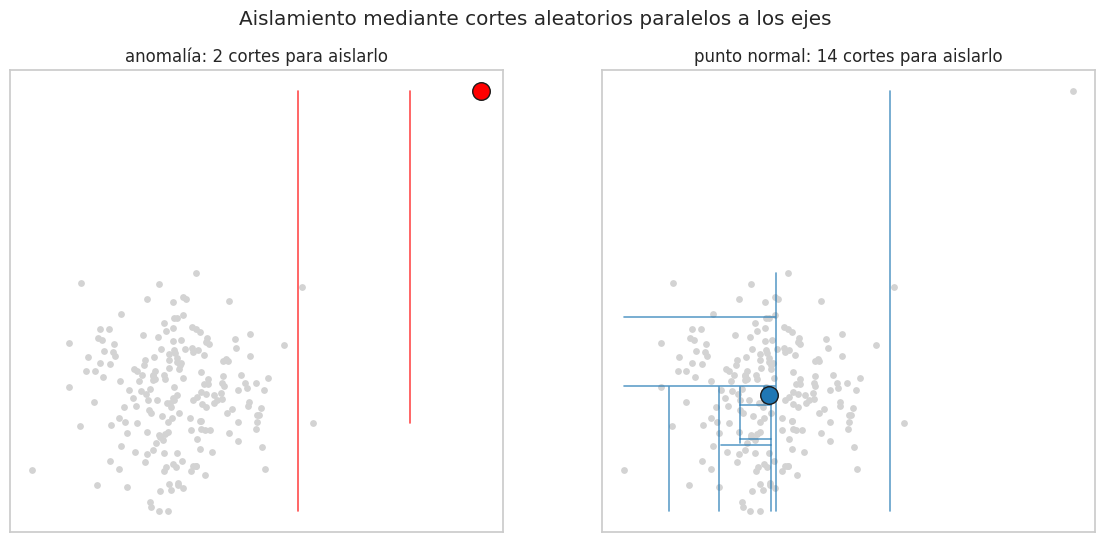

Cortes medios para aislar  ->  anomalía: 2.0   |   punto normal: 12.9


In [ ]:
rng_geo = np.random.RandomState(7)
Xn, _ = make_blobs(n_samples=200, centers=[[0, 0]], cluster_std=0.7, random_state=7)
X_geo = np.vstack([Xn, [[4.5, 4.0]]])                  # añadimos una anomalía clara
idx_anom = len(X_geo) - 1
idx_norm = int(np.argmin(np.linalg.norm(Xn - Xn.mean(0), axis=1)))   # punto más central

def camino_aislamiento(X, idx, rng):
    """Simula un iTree para el punto idx: cortes aleatorios paralelos a los ejes
    (dentro de la caja que aún contiene al punto) hasta dejarlo solo.
    Devuelve la lista de cortes (dim, valor, esquina_min, esquina_max)."""
    inside = np.ones(len(X), bool); cuts = []
    while inside.sum() > 1:
        pts = X[inside]; lo, hi = pts.min(0), pts.max(0)
        dims = [d for d in range(X.shape[1]) if hi[d] > lo[d]]
        if not dims:
            break
        d = rng.choice(dims)                       # variable al azar
        p = rng.uniform(lo[d], hi[d])              # corte al azar
        cuts.append((d, p, lo.copy(), hi.copy()))
        inside = inside & (X[:, d] < p if X[idx, d] < p else X[:, d] >= p)  # lado del punto
    return cuts

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (idx, etq, col) in zip(axes, [(idx_anom, 'anomalía', 'red'),
                                      (idx_norm, 'punto normal', 'tab:blue')]):
    cuts = camino_aislamiento(X_geo, idx, np.random.RandomState(0))
    ax.scatter(X_geo[:, 0], X_geo[:, 1], s=15, c='lightgray')
    for d, p, lo, hi in cuts:                       # dibujar cada corte dentro de su caja
        if d == 0: ax.plot([p, p], [lo[1], hi[1]], c=col, lw=1.2, alpha=.7)
        else:      ax.plot([lo[0], hi[0]], [p, p], c=col, lw=1.2, alpha=.7)
    ax.scatter(*X_geo[idx], s=160, c=col, edgecolor='k', zorder=3)
    ax.set_title(f'{etq}: {len(cuts)} cortes para aislarlo')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Aislamiento mediante cortes aleatorios paralelos a los ejes'); plt.show()

# Promedio sobre muchas simulaciones (cada iTree es aleatorio)
na = np.mean([len(camino_aislamiento(X_geo, idx_anom, np.random.RandomState(s))) for s in range(200)])
nn = np.mean([len(camino_aislamiento(X_geo, idx_norm, np.random.RandomState(s))) for s in range(200)])
print(f'Cortes medios para aislar  ->  anomalía: {na:.1f}   |   punto normal: {nn:.1f}')

La anomalía se aísla en **~2 cortes** (su gran caja vacía colapsa de golpe), mientras que el punto normal necesita **~13** (hay que separarlo uno a uno de sus muchos vecinos). Esa diferencia en la **longitud de camino** es, literalmente, la señal que mide Isolation Forest: **camino corto ⇒ anómalo; camino largo ⇒ normal.**

Se aprecia también la **limitación geométrica** del método: los cortes son **paralelos a los ejes**, así que las "cajas" son hiper-rectángulos. Estructuras anómalas orientadas en **diagonal** se capturan peor (lo resuelve la *Extended Isolation Forest*, que usa cortes con pendiente aleatoria).

## <font color="steelblue">2.4. La puntuación de anomalía</font>

Para que la puntuación sea **comparable entre conjuntos de distinto tamaño**, $E[h(x)]$ se normaliza por la longitud media de camino esperada al buscar un punto en un árbol binario de $n$ elementos (equivalente a una búsqueda fallida en un BST):

$$c(n) = 2H(n-1) - rac{2(n-1)}{n}, \qquad H(i) pprox \ln(i) + 0.5772\;(	ext{Euler–Mascheroni}).$$

La **puntuación de anomalía** combina ambas:

$$s(x, n) = 2^{-\dfrac{E[h(x)]}{c(n)}}.$$

El exponente es el cociente entre el camino observado y el "camino típico" $c(n)$. Analizando los límites de esa expresión se ve por qué la escala es tan cómoda:

* si $E[h(x)] 	o 0$ (se aísla nada más empezar) ⇒ $s 	o 2^{0}=1$ → **anomalía clara**;
* si $E[h(x)] 	o n-1$ (camino máximo) ⇒ $s 	o 0$ → punto **muy normal**;
* si $E[h(x)] 	o c(n)$ (camino típico) ⇒ $s 	o 2^{-1}=0.5$ → indistinguible.

Regla práctica: $s$ cercano a **1** = anomalía; $s \ll 0.5$ = normal; si **todos** rondan 0.5, no hay anomalías destacables.

## <font color="steelblue">2.5. El algoritmo paso a paso</font>

Reuniendo las piezas, el método tiene una fase de **entrenamiento** (construir el bosque) y otra de **puntuación**:

**Entrenamiento — `iForest(X, t, ψ)`**
```
para cada uno de los t árboles:
    X' ← submuestra aleatoria de tamaño ψ de X
    construir un iTree(X') con altura límite l = ceil(log2 ψ):
        si |X'| ≤ 1 o se alcanza l:  devolver hoja (guardando |X'|)
        elegir variable q al azar
        elegir corte p ~ Uniforme(min(X'_q), max(X'_q))
        nodo_izq ← iTree( X' con x_q <  p )
        nodo_der ← iTree( X' con x_q ≥  p )
```

**Puntuación — para cada punto x**
```
para cada árbol: recorrer x hasta su hoja  →  h_i(x) = aristas + c(tamaño_hoja)
E[h(x)] ← promedio de h_i(x) sobre los t árboles
s(x) ← 2^( - E[h(x)] / c(ψ) )
```

El coste es del orden de $O(t\,\psi \log \psi)$ en entrenamiento y la memoria es **constante** (cada árbol solo ve $\psi$ puntos), lo que explica por qué **escala a datos enormes y de alta dimensión**.

## <font color="steelblue">2.6. Submuestreo, *swamping* y *masking*</font>

Cada árbol se entrena con una **submuestra** de tamaño $\psi$ (por defecto **256**), no con todos los datos. No es solo por eficiencia: geométricamente, el submuestreo **"adelgaza" la nube** y resuelve dos patologías clásicas:

* ***Swamping*** — puntos normales pegados a un grupo de anomalías que se marcan por error. Al submuestrear, se separan de ese amontonamiento.
* ***Masking*** — un grupo **denso** de anomalías que, por ser numeroso, se comporta como una región "normal" y se esconde. Al tomar pocas muestras, ese grupo vuelve a parecer escaso y aislable.

Por eso, contra la intuición, **muestras pequeñas suelen detectar mejor** que usar todo el conjunto.









## <font color="steelblue">2.7. Ventajas, inconvenientes y alternativas</font>

| | Isolation Forest |
|---|---|
| ✅ | **Rápido y escalable** (lineal, memoria baja); **pocos parámetros**; no asume distribución; no calcula distancias/densidades; va bien en **alta dimensión**. |
| ⚠️ | Es **aleatorio** (fijar `random_state`); detector **global**, puede fallar con **anomalías locales** o densidades muy variables; cortes **paralelos a los ejes** (sesgo que corrige la *Extended Isolation Forest*); hay que **fijar la contaminación** para el umbral; poca interpretabilidad por variable. |

**Frente a otros detectores:** el **LOF** mide densidad **local** (mejor para anomalías locales, más lento); el **One-Class SVM** aprende una **frontera** (potente pero costoso y sensible al kernel); el **Elliptic Envelope** asume datos **gaussianos** (rápido pero rígido). Como vimos en 2.3, la **Extended Isolation Forest** sustituye los cortes paralelos a los ejes por hiperplanos de orientación aleatoria.

## <font color="steelblue">2.8. Extended Isolation Forest (EIF)</font>

En 2.3 vimos la principal **limitación geométrica** de Isolation Forest: como cada corte es un **hiperplano paralelo a un eje**, las "cajas" de aislamiento son hiper-rectángulos. Esto introduce un **artefacto** en el mapa de puntuaciones: a lo largo de las **rectas paralelas a los ejes que pasan por el centro** de la nube aparecen "**fantasmas**", franjas en las que la puntuación de anomalía es **artificialmente baja**. Dicho de otro modo, dos puntos a la **misma distancia** del centro pueden recibir puntuaciones distintas según caigan **sobre un eje** o **en diagonal**, lo que no tiene sentido si la nube es aproximadamente isótropa.

La **Extended Isolation Forest** (Hariri, Kind & Brunner, 2021) corrige el sesgo cambiando una sola cosa del iTree: en cada nodo, en lugar de elegir **una variable y un umbral**, se elige un **hiperplano de orientación aleatoria**. Formalmente, se toma:

* un **vector normal** $\mathbf{n}$ con cada componente $\sim \mathcal{N}(0,1)$ (define una dirección al azar), y
* un **punto de intercepto** $\mathbf{p}$ uniforme dentro del rango de los datos del nodo.

y el reparto se hace según el **signo de la proyección**:

$$(\mathbf{x}-\mathbf{p})\cdot \mathbf{n} \le 0 \;\Rightarrow\; \text{rama izquierda},\qquad >0 \;\Rightarrow\; \text{rama derecha}.$$

Los cortes ya **no son paralelos a los ejes**, sino oblicuos en cualquier dirección, de modo que el aislamiento se vuelve **simétrico ante rotaciones** y el mapa de puntuaciones es **radial**, sin franjas fantasma.

**Nivel de extensión (*extension level*).** Es un parámetro que fija **cuántas componentes** del vector normal son no nulas. Con $p$ variables:

* extensión **máxima** $=p-1$: hiperplanos totalmente oblicuos (la EIF "completa");
* extensión **mínima** $=0$: solo una componente activa $\Rightarrow$ se **recupera el Isolation Forest clásico** (cortes paralelos a los ejes).

Así, EIF **generaliza** a IF: el IF estándar es el caso particular de extensión 0. La **longitud de camino** $h(x)$ y la **puntuación** $s(x)=2^{-E[h(x)]/c(\psi)}$ se calculan **exactamente igual** (sección 2.4).

**¿Cuándo merece la pena?** Cuando los datos tienen estructura **diagonal o curva**, o cuando se necesita un **mapa de anomalía sin sesgo** para comparar puntuaciones de forma fiable. Si los datos están bien alineados con los ejes, la diferencia es pequeña. Una nota práctica: `scikit-learn` **no** incluye EIF (existe el paquete externo `eif`); en 4.4 usaremos una **implementación propia y compacta** para ver el efecto con claridad.

# <font color="steelblue">3. Isolation Forest en Python</font>

`sklearn.ensemble.IsolationForest`. Parámetros principales:

* `n_estimators` *(def. 100)*: número de árboles $t$. Más árboles → puntuación más **estable** (converge rápido; 100–300 suele bastar).
* `max_samples` *(def. 'auto' = 256)*: tamaño de la submuestra $\psi$. Valores pequeños mitigan *swamping*/*masking* (sección 2.6).
* `contamination` *(def. 'auto')*: proporción esperada de anomalías; **fija el umbral**, no cambia las puntuaciones.
* `max_features` *(def. 1.0)*: fracción de variables candidatas por nodo.
* `random_state`: reproducibilidad (el método es aleatorio).



## <font color="steelblue">3.1. Cómo puntúa y decide scikit-learn</font>

La convención de scikit-learn para detectores conviene entenderla bien, porque los signos despistan:

* **`score_samples(X)`** — devuelve la puntuación de anomalía **con el signo cambiado** respecto al artículo: es aproximadamente $-s(x)$, de modo que **cuanto menor (más negativo), más anómalo**. Por eso, para usar un "grado de anomalía" creciente tomamos **`-score_samples(X)`**.
* **`offset_`** — el **umbral** interno. Con `contamination='auto'` vale $-0.5$ (equivale a $s=0.5$); si fijamos `contamination=c`, se sitúa en el **percentil $100c$** de las puntuaciones, de forma que esa fracción quede marcada.
* **`decision_function(X) = score_samples(X) − offset_`** — centra el umbral en **0**: **negativo ⇒ anomalía**, positivo ⇒ normal.
* **`predict(X)`** — aplica ese umbral y devuelve **+1** (normal) o **−1** (anomalía).

Geométricamente, la curva `decision_function = 0` es exactamente la **frontera** que envuelve la región "normal" (la dibujaremos en el ejemplo 4.1). Subir `contamination` **relaja** esa frontera (encierra menos puntos como normales); bajarla la **ciñe**.

> **Resumen de uso:** `predict` para una decisión binaria con un umbral fijo; **`-score_samples`** como puntuación continua para ordenar, calcular ROC/PR o elegir el umbral a posteriori.



# <font color="steelblue">4. Aplicaciones</font>



## <font color="steelblue">4.1. Ejemplo sintético en 2D</font>

Generamos dos grupos compactos de puntos **normales** y añadimos puntos **dispersos** (anomalías) repartidos por el plano. Trabajar en 2D nos permite **ver** la frontera de decisión y las puntuaciones.

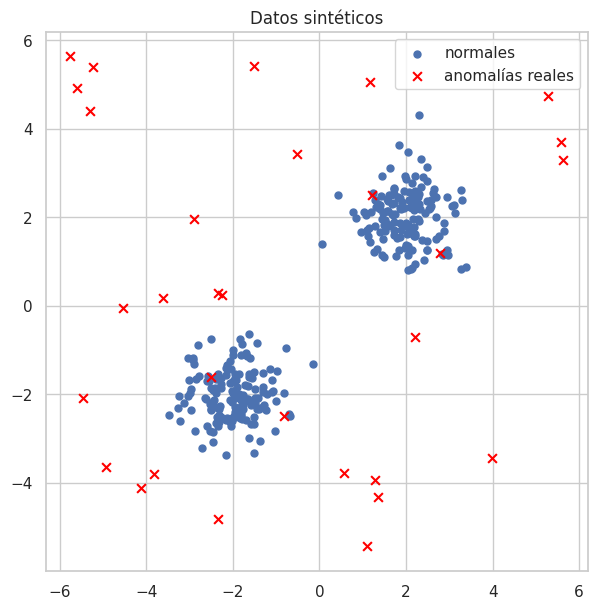

In [ ]:
rng = np.random.RandomState(RNG)

X_norm, _ = make_blobs(n_samples=300, centers=[[2, 2], [-2, -2]],
                       cluster_std=0.6, random_state=RNG)
X_anom = rng.uniform(low=-6, high=6, size=(30, 2))
X = np.vstack([X_norm, X_anom])

plt.figure(figsize=(7, 7))
plt.scatter(X_norm[:, 0], X_norm[:, 1], s=25, label='normales')
plt.scatter(X_anom[:, 0], X_anom[:, 1], s=40, c='red', marker='x', label='anomalías reales')
plt.legend(); plt.title('Datos sintéticos'); plt.show()

Ajustamos el Isolation Forest indicando una **contaminación del 10 %** y vemos cuántas detecta.

In [ ]:
iso = IsolationForest(n_estimators=200, contamination=0.1, random_state=RNG).fit(X)
pred = iso.predict(X)
print(f'Anomalías detectadas: {int((pred == -1).sum())} de {len(X)}')

Anomalías detectadas: 33 de 330


El modelo marca **33 puntos** como anómalos (el 10 % que le pedimos con `contamination`). Visualizamos la **frontera de decisión** (`decision_function = 0`, la que describimos en 3.1) y coloreamos por la puntuación.

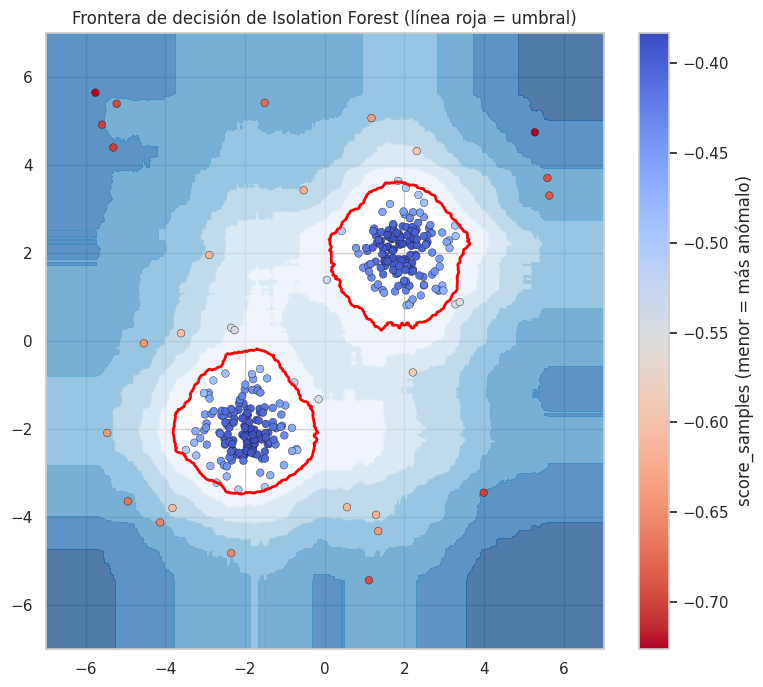

In [ ]:
xx, yy = np.meshgrid(np.linspace(-7, 7, 400), np.linspace(-7, 7, 400))
Z = iso.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 8))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 8), cmap='Blues_r', alpha=.7)
plt.contour(xx, yy, Z, levels=[0], colors='red', linewidths=2)
sc = plt.scatter(X[:, 0], X[:, 1], c=iso.score_samples(X), cmap='coolwarm_r', s=30, edgecolor='k', lw=.3)
plt.colorbar(sc, label='score_samples (menor = más anómalo)')
plt.title('Frontera de decisión de Isolation Forest (línea roja = umbral)')
plt.show()

La línea roja es el **umbral** (`decision_function = 0`): dentro quedan los dos grupos densos (normal), y fuera, las regiones poco pobladas donde caen las anomalías. La frontera **envuelve las zonas densas** sin asumir ninguna forma concreta de la distribución.



### Efecto del parámetro `contamination`

In [ ]:
for c in [0.02, 0.05, 0.10, 0.20]:
    p = IsolationForest(n_estimators=200, contamination=c, random_state=RNG).fit_predict(X)
    print(f'contamination={c:>4} -> {int((p==-1).sum()):>3} anomalías')

contamination=0.02 ->   7 anomalías
contamination=0.05 ->  17 anomalías
contamination= 0.1 ->  33 anomalías
contamination= 0.2 ->  66 anomalías


`contamination` no cambia las puntuaciones, solo **dónde se pone el umbral** (ciñe o relaja la frontera de 3.1). Como rara vez conocemos la proporción real, conviene calibrarlo y, sobre todo, **revisar las observaciones marcadas**.



## <font color="steelblue">4.2. Comparación con otros detectores</font>

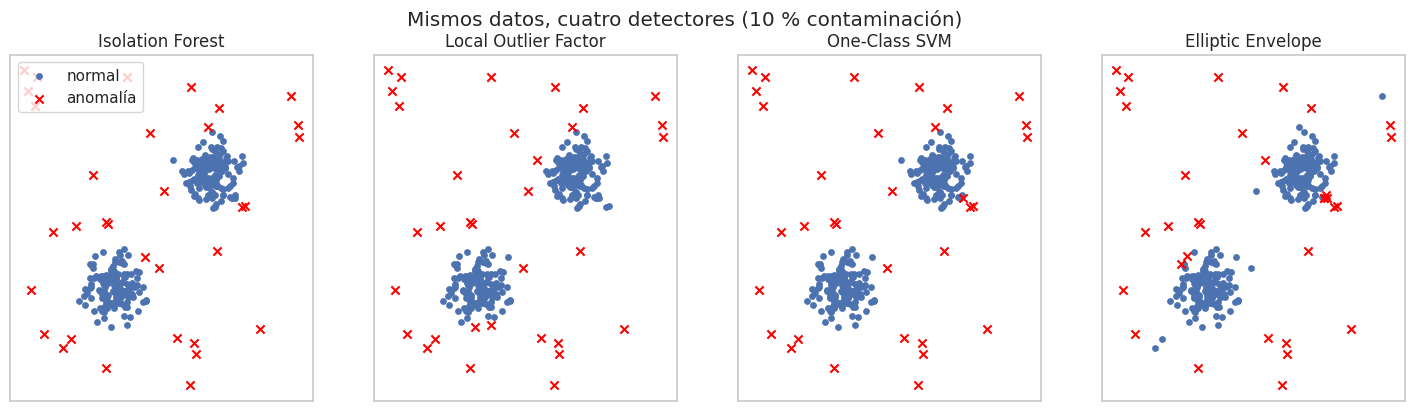

In [ ]:
detectores = {
    'Isolation Forest': IsolationForest(contamination=0.1, random_state=RNG),
    'Local Outlier Factor': LocalOutlierFactor(n_neighbors=20, contamination=0.1),
    'One-Class SVM': OneClassSVM(nu=0.1, gamma='scale'),
    'Elliptic Envelope': EllipticEnvelope(contamination=0.1, random_state=RNG),
}
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (nombre, modelo) in zip(axes, detectores.items()):
    p = modelo.fit_predict(X) if nombre == 'Local Outlier Factor' else modelo.fit(X).predict(X)
    ax.scatter(X[p == 1, 0],  X[p == 1, 1],  s=15, label='normal')
    ax.scatter(X[p == -1, 0], X[p == -1, 1], s=35, c='red', marker='x', label='anomalía')
    ax.set_title(nombre); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc='upper left'); plt.suptitle('Mismos datos, cuatro detectores (10 % contaminación)')
plt.show()

Los cuatro marcan el mismo **número** de anomalías (fijado por la contaminación), pero **no exactamente las mismas**: el *Elliptic Envelope* asume una frontera elíptica (gaussiana), el **LOF** es sensible a la densidad local, y **One-Class SVM** e **Isolation Forest** usan fronteras más flexibles.



## <font color="steelblue">4.3. Caso real: vinos atípicos</font>

Usamos el dataset `wine` (178 vinos × 13 variables) para **detectar vinos atípicos** sin usar la clase para entrenar.

Vinos marcados como atípicos (5 %): 9 de 178


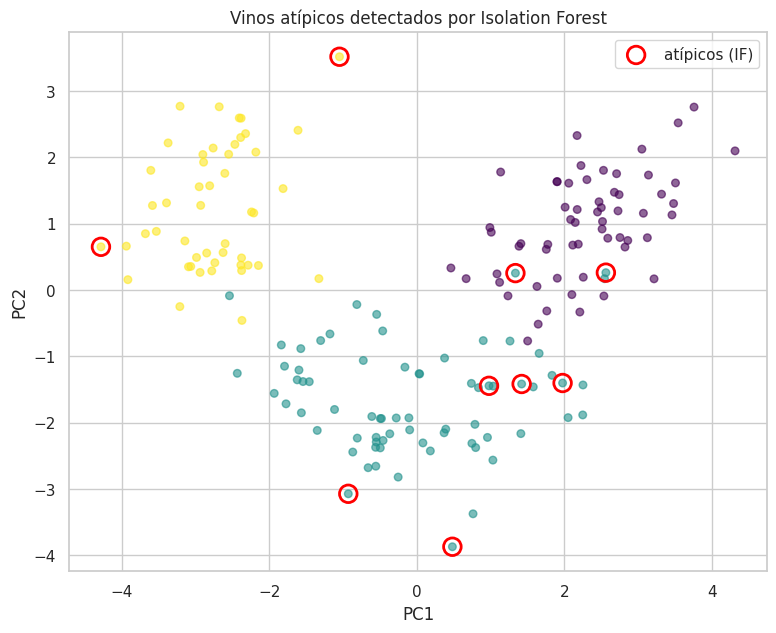

In [ ]:
wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)

iso_wine = IsolationForest(n_estimators=300, contamination=0.05, random_state=RNG).fit(X_wine)
pred_wine = iso_wine.predict(X_wine)
anom = np.where(pred_wine == -1)[0]
print(f'Vinos marcados como atípicos (5 %): {len(anom)} de {len(X_wine)}')

proj = PCA(n_components=2).fit_transform(X_wine)
plt.figure(figsize=(9, 7))
plt.scatter(proj[:, 0], proj[:, 1], c=wine.target, cmap='viridis', s=30, alpha=.6)
plt.scatter(proj[anom, 0], proj[anom, 1], s=160, facecolors='none',
            edgecolors='red', linewidths=2, label='atípicos (IF)')
plt.legend(); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Vinos atípicos detectados por Isolation Forest'); plt.show()

Los vinos atípicos caen en los **bordes** de la nube en el plano PCA. Isolation Forest **señala candidatos** a revisar; la decisión final requiere conocimiento del dominio.

## <font color="steelblue">4.4. Extended Isolation Forest en la práctica</font>

Implementamos una **EIF compacta** (didáctica) con cortes oblicuos y comparamos su **mapa de puntuaciones** con el del Isolation Forest estándar sobre un **único grupo circular** de puntos: es el ejemplo canónico donde aflora el **artefacto axial** de 2.8.

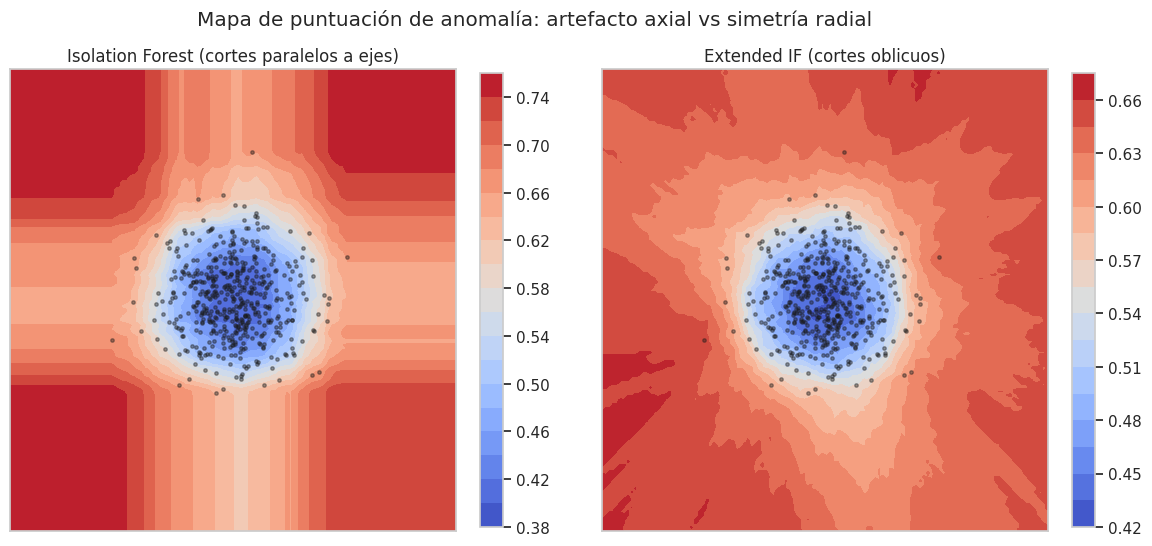

In [ ]:
def c_factor(n):
    # longitud media de camino en un árbol binario de n elementos (sección 2.4)
    n = np.asarray(n, float)
    H = np.log(np.maximum(n - 1, 1)) + 0.5772156649          # número armónico ≈ ln+γ
    return np.where(n > 1, 2 * H - 2 * (n - 1) / np.maximum(n, 1), 0.0)

class ExtendedIForest:
    # Isolation Forest con cortes OBLICUOS (hiperplano de orientación aleatoria).
    # extension_level=None -> extensión máxima (p-1); 0 equivale al IF clásico.
    def __init__(self, n_trees=120, sample_size=256, extension_level=None, random_state=0):
        self.n_trees, self.sample_size = n_trees, sample_size
        self.extension_level, self.random_state = extension_level, random_state
    def _fit(self, X, depth, lim):
        n = len(X)
        if depth >= lim or n <= 1:
            return {'leaf': True, 'size': n}
        nrm = self.rng.normal(size=self.dim)                  # vector normal aleatorio
        k = self.dim - 1 - self.extension_level               # componentes a anular
        if k > 0:
            nrm[self.rng.choice(self.dim, size=k, replace=False)] = 0.0
        p = self.rng.uniform(X.min(0), X.max(0))              # intercepto aleatorio
        proj = (X - p) @ nrm
        L, R = X[proj <= 0], X[proj > 0]
        if len(L) == 0 or len(R) == 0:
            return {'leaf': True, 'size': n}
        return {'leaf': False, 'n': nrm, 'p': p,
                'L': self._fit(L, depth + 1, lim), 'R': self._fit(R, depth + 1, lim)}
    def fit(self, X):
        X = np.asarray(X, float); self.dim = X.shape[1]
        if self.extension_level is None: self.extension_level = self.dim - 1
        self.rng = np.random.RandomState(self.random_state)
        self.psi = min(self.sample_size, len(X)); lim = int(np.ceil(np.log2(self.psi)))
        self.trees = [self._fit(X[self.rng.choice(len(X), self.psi, replace=False)], 0, lim)
                      for _ in range(self.n_trees)]
        self.cpsi = float(c_factor(self.psi)); return self
    def _paths(self, X, node, depth):
        if node['leaf']:
            return np.full(len(X), depth + float(c_factor(node['size'])))
        proj = (X - node['p']) @ node['n']; out = np.empty(len(X)); mL = proj <= 0
        if mL.any():  out[mL]  = self._paths(X[mL],  node['L'], depth + 1)
        if (~mL).any(): out[~mL] = self._paths(X[~mL], node['R'], depth + 1)
        return out
    def anomaly_score(self, X):                                # mayor = más anómalo
        X = np.asarray(X, float); h = np.zeros(len(X))
        for t in self.trees: h += self._paths(X, t, 0)
        return 2 ** (-(h / len(self.trees)) / self.cpsi)

# un único grupo circular centrado en el origen
X_blob, _ = make_blobs(n_samples=500, centers=[[0, 0]], cluster_std=1.0, random_state=RNG)
ifo  = IsolationForest(n_estimators=150, random_state=RNG).fit(X_blob)
eifo = ExtendedIForest(n_trees=150, random_state=RNG).fit(X_blob)

gx, gy = np.meshgrid(np.linspace(-6, 6, 120), np.linspace(-6, 6, 120))
G = np.c_[gx.ravel(), gy.ravel()]
Z_if  = (-ifo.score_samples(G)).reshape(gx.shape)     # IF estándar (mayor = más anómalo)
Z_eif = eifo.anomaly_score(G).reshape(gx.shape)       # EIF

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, (Z, tit) in zip(ax, [(Z_if, 'Isolation Forest (cortes paralelos a ejes)'),
                            (Z_eif, 'Extended IF (cortes oblicuos)')]):
    cf = a.contourf(gx, gy, Z, levels=20, cmap='coolwarm')
    a.scatter(X_blob[:, 0], X_blob[:, 1], s=6, c='k', alpha=.4)
    a.set_title(tit); a.set_xticks([]); a.set_yticks([]); fig.colorbar(cf, ax=a, fraction=.046)
plt.suptitle('Mapa de puntuación de anomalía: artefacto axial vs simetría radial'); plt.show()

In [ ]:
# Comprobación numérica del artefacto: puntos al MISMO radio, sobre los ejes vs en diagonal
r = 4.0
eje  = np.array([[r, 0], [0, r], [-r, 0], [0, -r]])
diag = np.array([[r/np.sqrt(2), r/np.sqrt(2)], [-r/np.sqrt(2), r/np.sqrt(2)]])
print('Puntuación media a radio r=4 (mayor = más anómalo):')
print(f'  IF  estándar : eje={(-ifo.score_samples(eje)).mean():.3f}   diagonal={(-ifo.score_samples(diag)).mean():.3f}')
print(f'  Extended IF  : eje={eifo.anomaly_score(eje).mean():.3f}   diagonal={eifo.anomaly_score(diag).mean():.3f}')

Puntuación media a radio r=4 (mayor = más anómalo):
  IF  estándar : eje=0.646   diagonal=0.728
  Extended IF  : eje=0.631   diagonal=0.622


En el mapa del **IF estándar** se aprecian franjas ("fantasmas") de menor anomalía a lo largo de los **ejes**: dos puntos al **mismo radio** reciben puntuaciones distintas (eje ≈ 0.65 frente a diagonal ≈ 0.73). La **Extended IF**, con cortes oblicuos, produce un mapa **radial** y casi simétrico (eje ≈ diagonal ≈ 0.62), eliminando el sesgo. Cuando la estructura de los datos es diagonal o curva, esta diferencia se vuelve relevante.

## <font color="steelblue">4.5. De la longitud de camino a la puntuación, y la elección del umbral</font>

Cerramos el círculo entre la **teoría de 2.4** y la práctica. Sobre los datos sintéticos de 4.1 (de los que **sí conocemos** la etiqueta), hacemos dos cosas:

1. **Recuperar la longitud de camino** $E[h(x)]$ a partir de la puntuación. Como $s(x)=2^{-E[h(x)]/c(\psi)}$, invirtiendo: $E[h(x)] = -c(\psi)\,\log_2 s(x)$, con $s(x) = -\texttt{score\_samples}(x)$.
2. **Elegir el umbral con la curva precision-recall** (en vez de fijar `contamination` a ciegas), buscando el que **maximiza F1** —en producción se elegiría según el coste del negocio (sección 5.3)—.

In [ ]:
# etiquetas conocidas del ejemplo 4.1: las 30 últimas filas son anomalías
y_syn = np.r_[np.zeros(len(X_norm)), np.ones(len(X_anom))].astype(int)
s_paper = -iso.score_samples(X)                       # s(x) del artículo (mayor = más anómalo)

psi = min(256, len(X)); cpsi = float(c_factor(psi))
Eh = -cpsi * np.log2(s_paper)                         # longitud de camino recuperada
ia, ino = int(np.argmax(s_paper)), int(np.argmin(s_paper))
print(f'c(psi={psi}) = {cpsi:.2f}')
print(f'punto MÁS anómalo : s={s_paper[ia]:.3f}  ->  E[h(x)]={Eh[ia]:.1f}  (camino corto)')
print(f'punto MÁS normal  : s={s_paper[ino]:.3f}  ->  E[h(x)]={Eh[ino]:.1f}  (camino largo)')

c(psi=256) = 10.24
punto MÁS anómalo : s=0.726  ->  E[h(x)]=4.7  (camino corto)
punto MÁS normal  : s=0.383  ->  E[h(x)]=14.2  (camino largo)


PR-AUC = 0.899
Umbral que maximiza F1 = 0.549  ->  F1 = 0.897
Matriz de confusión [filas=real, cols=predicho]:
[[298   2]
 [  4  26]]


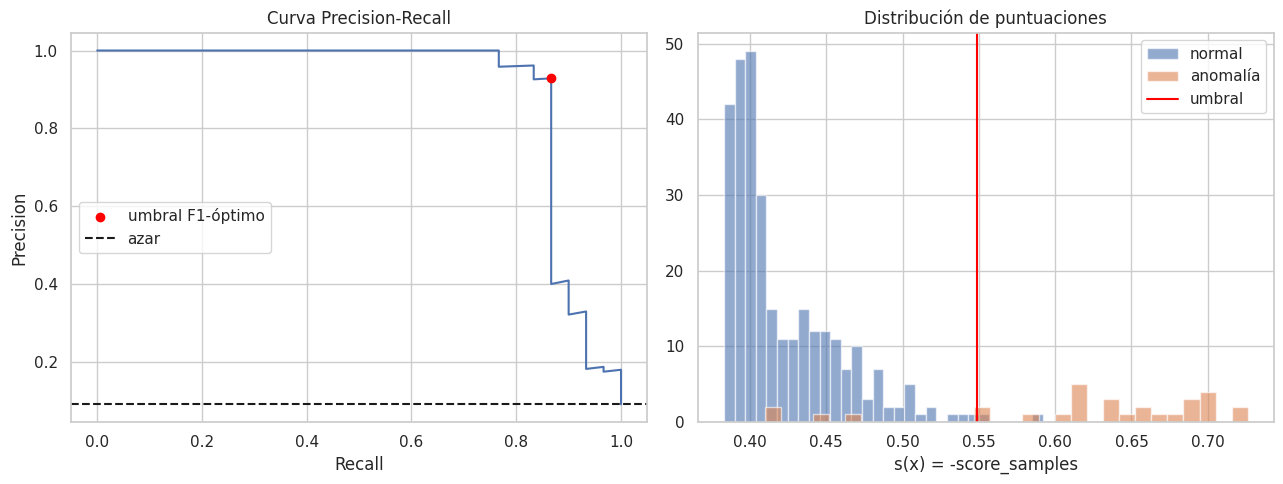

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix, average_precision_score
prec, rec, thr = precision_recall_curve(y_syn, s_paper)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
kbest = int(np.nanargmax(f1)); umbral = thr[min(kbest, len(thr) - 1)]
pred_umbral = (s_paper >= umbral).astype(int)
print(f'PR-AUC = {average_precision_score(y_syn, s_paper):.3f}')
print(f'Umbral que maximiza F1 = {umbral:.3f}  ->  F1 = {f1[kbest]:.3f}')
print('Matriz de confusión [filas=real, cols=predicho]:'); print(confusion_matrix(y_syn, pred_umbral))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(rec, prec); ax[0].scatter(rec[kbest], prec[kbest], c='red', zorder=3, label='umbral F1-óptimo')
ax[0].axhline(y_syn.mean(), ls='--', c='k', label='azar'); ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Curva Precision-Recall'); ax[0].legend()
ax[1].hist(s_paper[y_syn == 0], bins=30, alpha=.6, label='normal')
ax[1].hist(s_paper[y_syn == 1], bins=30, alpha=.6, label='anomalía')
ax[1].axvline(umbral, c='red', label='umbral'); ax[1].set_xlabel('s(x) = -score_samples'); ax[1].legend()
ax[1].set_title('Distribución de puntuaciones'); plt.tight_layout(); plt.show()

El punto más anómalo tiene una longitud de camino **corta** ($E[h]\approx 5$) y $s\approx 0.73$; el más normal, un camino **largo** ($E[h]\approx 14$) y $s\approx 0.38$ — exactamente lo que predice la teoría de 2.4. Al elegir el **umbral por la curva PR** (F1-óptimo ≈ 0.55) obtenemos una detección equilibrada (F1 ≈ 0.90), sin haber tenido que adivinar `contamination`: separamos así la **puntuación** (que ordena) de la **decisión** (el umbral), que se fija según el coste de revisar cada caso.

## <font color="steelblue">4.6. Detección de novedades (semi-supervisada)</font>

Hasta ahora hemos hecho **detección de *outliers***: el conjunto de entrenamiento **ya contenía** anomalías. En la **detección de novedades** (sección 1) el planteamiento es distinto: entrenamos **solo con datos normales** ("limpios") y queremos decidir si una observación **nueva** es atípica. Dos diferencias clave:

* el entrenamiento **no lleva contaminación** (asumimos que todo es normal);
* con `LocalOutlierFactor` hay que indicar **`novelty=True`** y entonces se usa **`predict`** sobre los datos nuevos (no `fit_predict`). `IsolationForest` y `OneClassSVM` también sirven, entrenándolos sobre los datos normales.

Entrenamos con un único grupo normal y evaluamos sobre un conjunto **nuevo** que mezcla puntos normales y novedades.

LOF (novelty=True)    recall novedad=0.90  precision=0.95  marcadas=19
Isolation Forest      recall novedad=1.00  precision=0.51  marcadas=39


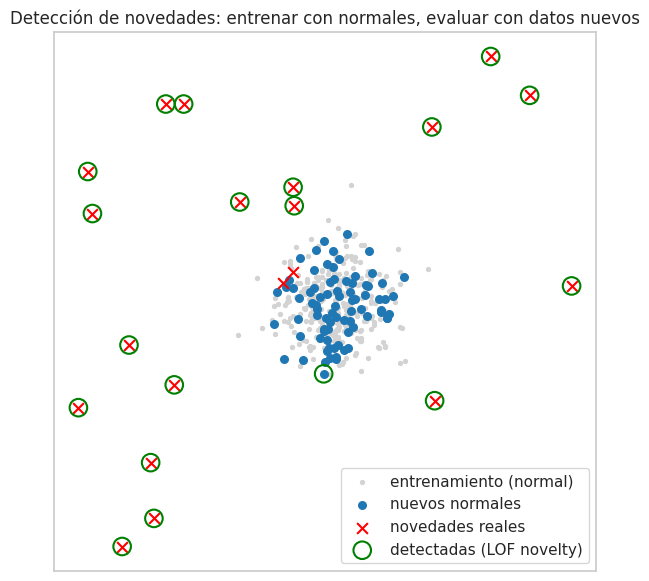

In [ ]:
# entrenamiento SOLO con datos normales
X_train_nov, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=0.7, random_state=RNG)
# conjunto nuevo: 80 normales + 20 novedades dispersas
rng_nov = np.random.RandomState(1)
X_in, _ = make_blobs(n_samples=80, centers=[[0, 0]], cluster_std=0.7, random_state=7)
X_out = rng_nov.uniform(-6, 6, size=(20, 2))
X_new = np.vstack([X_in, X_out]); y_new = np.r_[np.zeros(80), np.ones(20)].astype(int)

lof = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(X_train_nov)   # novelty=True -> predict
p_lof = (lof.predict(X_new) == -1).astype(int)
ifn = IsolationForest(n_estimators=200, random_state=RNG).fit(X_train_nov)
p_if = (ifn.predict(X_new) == -1).astype(int)

from sklearn.metrics import recall_score, precision_score
for nom, p in [('LOF (novelty=True)', p_lof), ('Isolation Forest', p_if)]:
    print(f'{nom:20s}  recall novedad={recall_score(y_new, p):.2f}  '
          f'precision={precision_score(y_new, p, zero_division=0):.2f}  marcadas={int(p.sum())}')

plt.figure(figsize=(7, 7))
plt.scatter(X_train_nov[:, 0], X_train_nov[:, 1], s=8, c='lightgray', label='entrenamiento (normal)')
plt.scatter(X_new[y_new == 0, 0], X_new[y_new == 0, 1], s=30, c='tab:blue', label='nuevos normales')
plt.scatter(X_new[y_new == 1, 0], X_new[y_new == 1, 1], s=60, c='red', marker='x', label='novedades reales')
flag = p_lof == 1
plt.scatter(X_new[flag, 0], X_new[flag, 1], s=160, facecolors='none', edgecolors='green',
            linewidths=1.5, label='detectadas (LOF novelty)')
plt.legend(); plt.title('Detección de novedades: entrenar con normales, evaluar con datos nuevos')
plt.xticks([]); plt.yticks([]); plt.show()

LOF(novelty=True)` detecta ~9 de cada 10 novedades con **alta precisión** (apenas marca normales): es el detector pensado para este escenario. `IsolationForest` entrenado solo con normales también las detecta **todas**, pero al usar su umbral por defecto marca **más** puntos (más falsos positivos); habría que **calibrar el umbral** como en 4.5. La elección depende de si prima no perder ninguna novedad (recall) o no molestar con falsas alarmas (precision).

## <font color="steelblue">4.7. Anomalías contextuales</font>

Una **anomalía contextual** (sección 1) es un valor **normal en general** pero **anómalo en su contexto**. El caso típico es una **serie temporal estacional**: un valor bajo no es raro de por sí, pero sí lo es **en mitad de un pico**. La clave es **incorporar el contexto** como variables: si solo miramos el valor, el detector no puede saber que está fuera de lugar.

Construimos una serie estacional e **inyectamos** un valor bajo justo en un máximo. Comparamos un Isolation Forest sobre **solo el valor** frente a otro sobre **el valor más variables de contexto** (la fase de la estación, vía seno y coseno).

Anomalía inyectada en t=125
  detectada con SOLO el valor : False
  detectada con CONTEXTO       : True


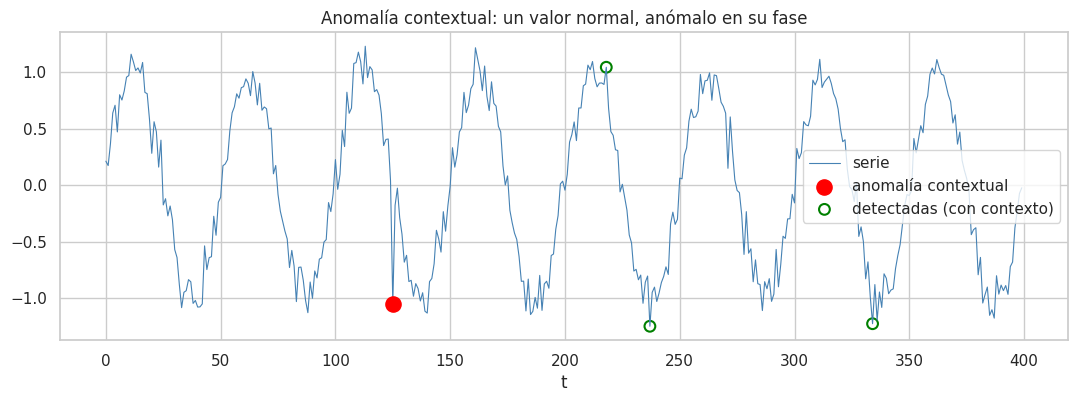

In [ ]:
N = 400; t = np.arange(N)
season = np.sin(2 * np.pi * t / 50)
serie = season + 0.12 * np.random.RandomState(0).randn(N)
k_ctx = 125                                   # índice del pico
serie[k_ctx] = season.min() - 0.05            # valor bajo en pleno máximo -> anomalía contextual

contexto = np.c_[np.sin(2 * np.pi * t / 50), np.cos(2 * np.pi * t / 50)]   # fase de la estación
if_valor    = IsolationForest(contamination=0.01, random_state=RNG).fit(serie.reshape(-1, 1))
if_contexto = IsolationForest(contamination=0.01, random_state=RNG).fit(np.c_[serie, contexto])
det_valor    = np.where(if_valor.predict(serie.reshape(-1, 1)) == -1)[0]
det_contexto = np.where(if_contexto.predict(np.c_[serie, contexto]) == -1)[0]
print(f'Anomalía inyectada en t={k_ctx}')
print(f'  detectada con SOLO el valor : {k_ctx in det_valor}')
print(f'  detectada con CONTEXTO       : {k_ctx in det_contexto}')

plt.figure(figsize=(13, 4))
plt.plot(t, serie, lw=.8, c='steelblue', label='serie')
plt.scatter(k_ctx, serie[k_ctx], s=120, c='red', zorder=3, label='anomalía contextual')
plt.scatter(det_contexto, serie[det_contexto], s=60, facecolors='none', edgecolors='green',
            linewidths=1.5, label='detectadas (con contexto)')
plt.legend(); plt.title('Anomalía contextual: un valor normal, anómalo en su fase'); plt.xlabel('t'); plt.show()

El detector sobre **solo el valor** **no** marca el punto (un valor bajo es perfectamente normal en la serie). Al añadir el **contexto** (la fase de la estación), el modelo aprende qué valores son esperables en cada momento y **sí** detecta el punto fuera de lugar. La moraleja: las anomalías contextuales exigen **ingeniería de variables** que capture el contexto (tiempo, estación, ubicación…).

## <font color="steelblue">4.8. Anomalías colectivas</font>

Una **anomalía colectiva** (sección 1) es un **conjunto de observaciones** que, **juntas**, son anómalas, aunque cada una por separado parezca normal. Ejemplo clásico: un **tramo plano** en una señal que normalmente oscila —cada valor individual es plausible, pero la **secuencia** no—. La estrategia es analizar **ventanas** en lugar de puntos: extraemos características de cada ventana deslizante (media, dispersión, rango) y aplicamos el detector sobre ellas.

Tramo plano en [200, 230) | ventanas detectadas dentro del tramo: 17 de 20 totales


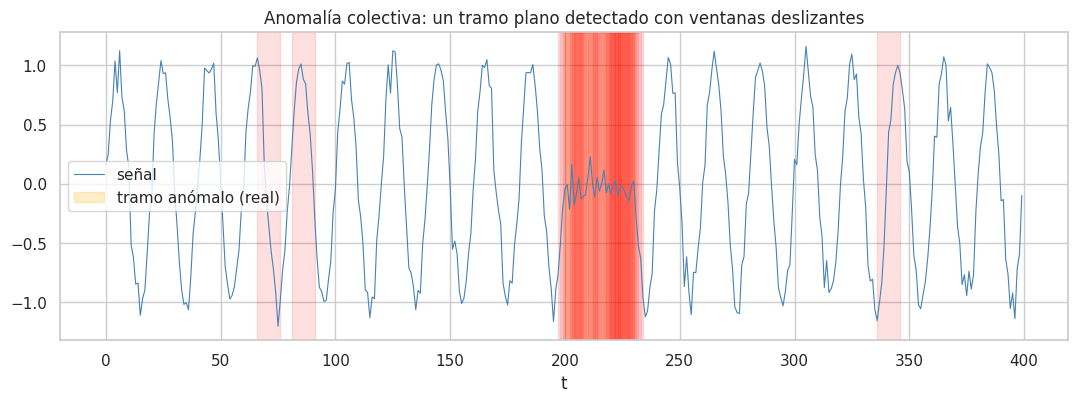

In [ ]:
M = 400
senal = np.sin(2 * np.pi * np.arange(M) / 20) + 0.1 * np.random.RandomState(1).randn(M)
a, b = 200, 230
senal[a:b] = 0.0 + 0.1 * np.random.RandomState(2).randn(b - a)   # tramo plano (anomalía colectiva)

w = 10
def caracteristicas_ventana(x, w):
    return np.array([[x[i:i+w].mean(), x[i:i+w].std(), x[i:i+w].max() - x[i:i+w].min()]
                     for i in range(len(x) - w + 1)])
V = caracteristicas_ventana(senal, w)                 # (media, desviación, rango) por ventana
if_win = IsolationForest(contamination=0.05, random_state=RNG).fit(V)
det_win = np.where(if_win.predict(V) == -1)[0]        # índices de ventanas anómalas (inicio de ventana)
en_tramo = [i for i in det_win if a - w < i < b]
print(f'Tramo plano en [{a}, {b}) | ventanas detectadas dentro del tramo: {len(en_tramo)} de {len(det_win)} totales')

plt.figure(figsize=(13, 4))
plt.plot(senal, lw=.8, c='steelblue', label='señal')
plt.axvspan(a, b, color='orange', alpha=.2, label='tramo anómalo (real)')
for i in det_win:                                     # sombrear ventanas detectadas
    plt.axvspan(i, i + w, color='red', alpha=.12)
plt.legend(); plt.title('Anomalía colectiva: un tramo plano detectado con ventanas deslizantes')
plt.xlabel('t'); plt.show()

Un detector punto a punto **no** vería nada raro (cada valor del tramo plano es normal), pero al describir cada **ventana** por su dispersión y rango, las ventanas del tramo plano tienen **desviación casi nula** y se aíslan fácilmente: la mayoría de las ventanas marcadas caen **dentro** del tramo anómalo. Las anomalías colectivas se atacan, pues, **agregando** la información en ventanas o segmentos.

## <font color="steelblue">4.9. Profundizar en los casos aislados</font>

Detectar es solo la mitad del trabajo. Una vez el modelo señala unos casos, un analista necesita **(1) priorizar** (revisar primero los más anómalos, no todos), **(2) entender** por qué cada caso es atípico y **(3) decidir cuántos** revisar. Reunimos cuatro herramientas para ello:

* **Panorama y top-K** — la puntuación `-score_samples` es **continua**: en vez de quedarnos con la marca binaria, ordenamos y miramos los **K más anómalos**.
* **Perfil del caso** — para un caso concreto, qué variables toman valores **extremos** (su perfil estandarizado, en *z*).
* **Atribución con SHAP** — como vimos, `TreeExplainer` **soporta** `IsolationForest` y reconstruye la longitud de camino: $\text{valor base}+\sum_i \phi_i = E[h(x)]$. Un $\phi_i<0$ **acorta** el camino (empuja hacia anomalía) y $\phi_i>0$ lo alarga (hacia normal). El *beeswarm* da la visión **global** (qué variables aíslan) y el *waterfall* la **local** (un caso).
* **Curva de ganancia** — si tenemos etiquetas, cuántas anomalías reales capturamos **revisando los K primeros**; responde a "¿cuántos conviene marcar?".

In [ ]:
import shap

def panorama_anomalias(scores, pred, k=10, nombre=''):
    # histograma de puntuaciones (marcados vs no) + barra de los k más anómalos
    scores = np.asarray(scores); order = np.argsort(scores)[::-1]; top = order[:k]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].hist(scores[pred == 0], bins=40, alpha=.7, label='no marcado')
    ax[0].hist(scores[pred == 1], bins=40, alpha=.7, color='crimson', label='marcado')
    ax[0].set_xlabel('grado de anomalía  (-score_samples)'); ax[0].set_ylabel('frecuencia')
    ax[0].set_title('Distribución de puntuaciones'); ax[0].legend()
    ax[1].barh(range(k), scores[top][::-1], color='crimson')
    ax[1].set_yticks(range(k)); ax[1].set_yticklabels([f'caso {i}' for i in top[::-1]], fontsize=8)
    ax[1].set_xlabel('grado de anomalía'); ax[1].set_title(f'Top-{k} más anómalos')
    plt.suptitle(nombre); plt.tight_layout(); plt.show()
    return top

def perfil_caso(X_std, idx, nombres, k=8, titulo=''):
    # valores estandarizados (z) de un caso: qué variables son extremas
    z = pd.Series(np.asarray(X_std)[idx], index=nombres)
    z = z.reindex(z.abs().sort_values(ascending=False).index).head(k).iloc[::-1]
    plt.figure(figsize=(8, 0.5 * len(z) + 1))
    plt.barh(range(len(z)), z.values, color=['crimson' if v > 0 else 'steelblue' for v in z])
    plt.yticks(range(len(z)), z.index); plt.axvline(0, c='k', lw=.8)
    plt.xlabel('valor estandarizado (z)'); plt.title(titulo); plt.tight_layout(); plt.show()
    return z

def explicar_anomalia_shap(iso, X_std, nombres, idx=None, max_display=12, titulo=''):
    # SHAP sobre Isolation Forest: explica E[h(x)] (longitud de camino)
    expl = shap.TreeExplainer(iso); sv = expl.shap_values(X_std)
    ev = float(np.ravel(expl.expected_value)[0])
    E = shap.Explanation(values=sv, base_values=np.full(len(X_std), ev),
                         data=np.asarray(X_std), feature_names=list(nombres))
    if idx is None:
        idx = int(np.argmin(ev + sv.sum(1)))     # el de camino más corto = más anómalo
    print(f'{titulo} | caso {idx}: camino E[h]={ev + sv[idx].sum():.2f} (base {ev:.2f})')
    shap.plots.waterfall(E[idx], max_display=max_display, show=False)
    plt.title(f'¿Por qué es anómalo el caso {idx}? (φ<0 acorta el camino)'); plt.show()
    shap.summary_plot(sv, np.asarray(X_std), feature_names=list(nombres),
                      max_display=max_display, show=False)
    plt.title('Impacto global en el aislamiento'); plt.show()
    return sv

def curva_ganancia(y, scores, nombre='', ks=(25, 50, 100, 200)):
    # con etiquetas: anomalías reales capturadas al revisar los K casos más anómalos
    y = np.asarray(y); scores = np.asarray(scores); order = np.argsort(scores)[::-1]
    detect = np.cumsum(y[order]); tot = int(y.sum()); n = len(y)
    plt.figure(figsize=(7, 5))
    plt.plot(np.arange(1, n + 1), detect, label='Isolation Forest')
    plt.plot([0, n], [0, tot], 'k--', label='azar')
    plt.plot([0, tot, n], [0, tot, tot], 'g:', label='ideal')
    plt.xlabel('nº de casos revisados (ordenados por anomalía)')
    plt.ylabel('anomalías reales encontradas')
    plt.title(f'Curva de ganancia — {nombre}'); plt.legend(); plt.tight_layout(); plt.show()
    return {K: (int(detect[K - 1]), round(detect[K - 1] / K, 3)) for K in ks if K <= n}

Las aplicamos al ejemplo de **vinos** (§4.3), donde las variables tienen nombre. Empezamos por el **panorama**: la puntuación continua y los vinos más atípicos.

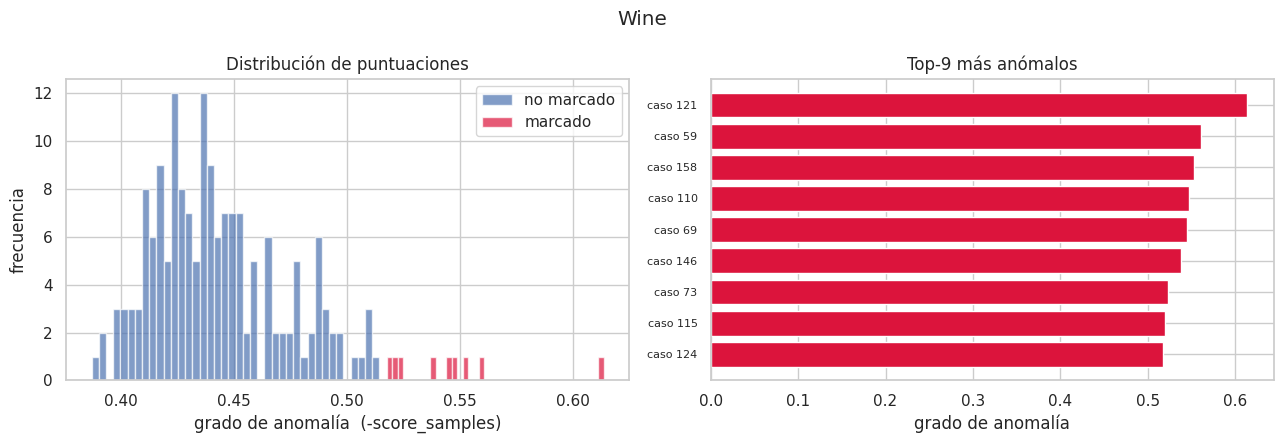

Vinos más atípicos (índices): [np.int64(121), np.int64(59), np.int64(158), np.int64(110), np.int64(69), np.int64(146), np.int64(73), np.int64(115), np.int64(124)]


In [ ]:
scores_wine = -iso_wine.score_samples(X_wine)        # grado de anomalía continuo
pred_wine01 = (pred_wine == -1).astype(int)
top_wine = panorama_anomalias(scores_wine, pred_wine01, k=9, nombre='Wine')
print('Vinos más atípicos (índices):', list(top_wine))

**Perfil del caso.** Para el vino más atípico, qué variables se salen de lo normal (en desviaciones estándar).

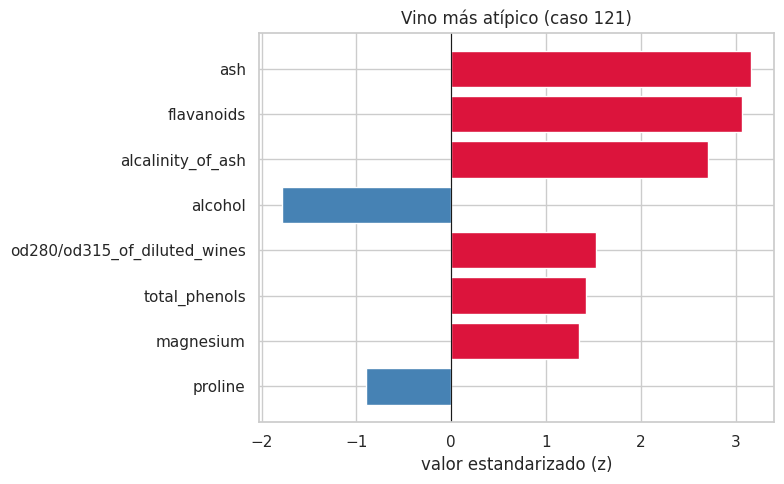

In [ ]:
z_top = perfil_caso(X_wine, int(top_wine[0]), wine.feature_names,
                    titulo=f'Vino más atípico (caso {int(top_wine[0])})')

**Atribución con SHAP.** El *waterfall* descompone el camino de ese vino variable a variable; el *beeswarm* resume qué variables aíslan en todo el conjunto.

Wine | caso 121: camino E[h]=6.70 (base 11.08)


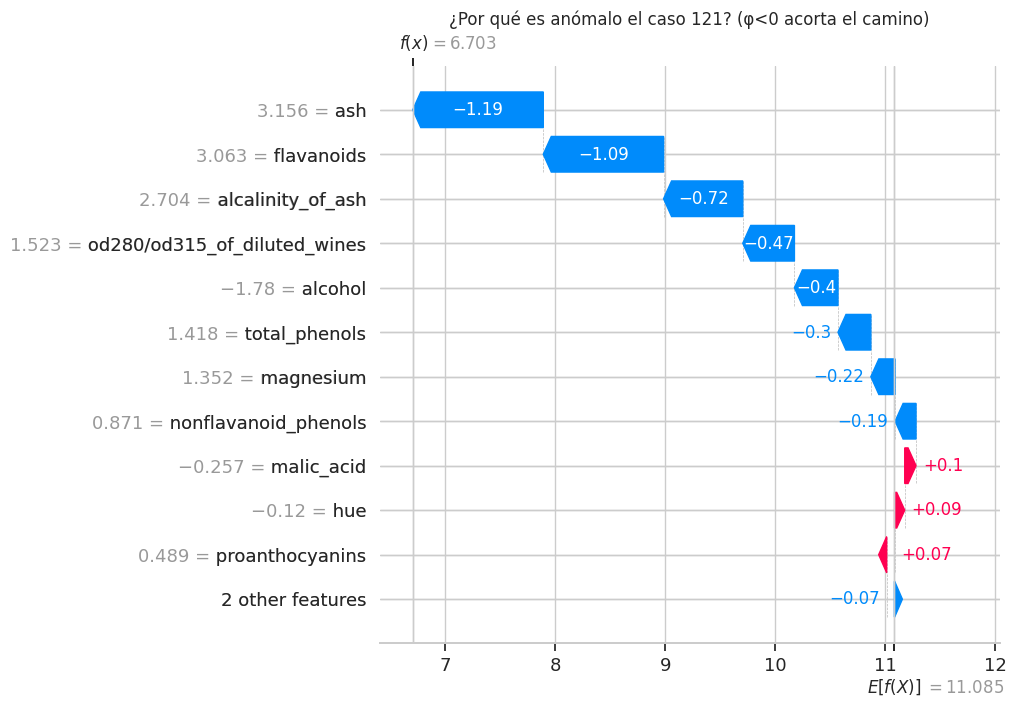

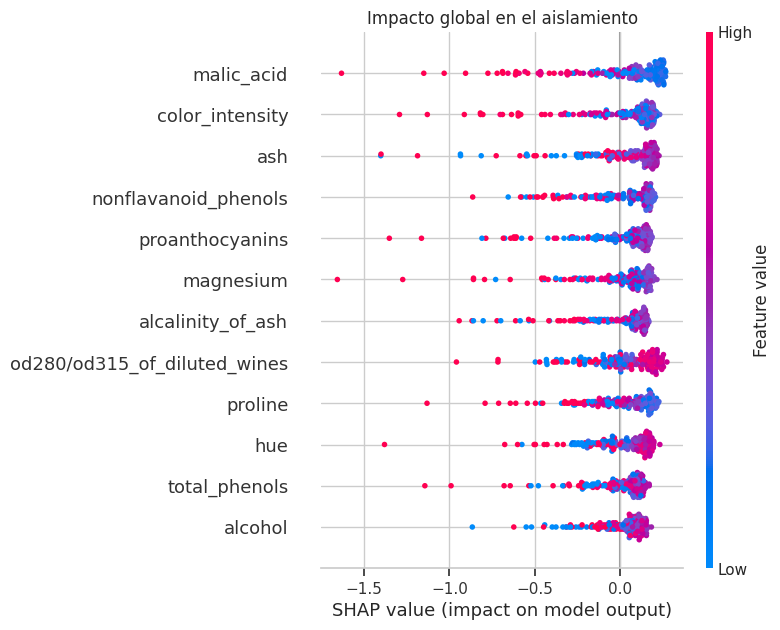

In [ ]:
sv_wine = explicar_anomalia_shap(iso_wine, X_wine, wine.feature_names,
                                 idx=int(top_wine[0]), titulo='Wine')

El perfil del vino más atípico muestra valores extremos en variables como *ash*, *flavanoids* o *alcalinity_of_ash* (varias desviaciones por encima de la media), y el *beeswarm* confirma que *malic_acid*, *color_intensity* y *ash* son las que más contribuyen a aislar vinos. Así pasamos de "este vino es raro" a **"es raro por estas variables"**, que es lo que permite actuar.

**¿Cuántos casos conviene marcar?** Aquí está la clave de tu observación. La puntuación **ordena** todos los casos; con etiquetas (las del sintético de 4.1) podemos ver cuántas anomalías reales capturamos según el número de casos que revisemos.

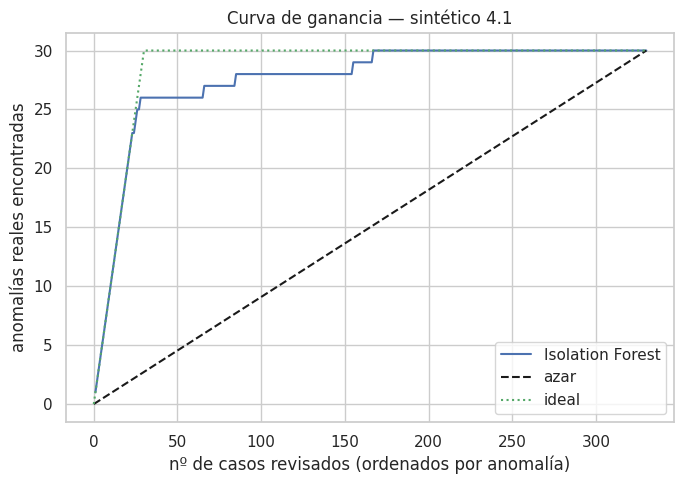

K -> (anomalías encontradas, precisión@K):
  top- 10: 10 de 30   precisión=1.0
  top- 25: 24 de 30   precisión=0.96
  top- 50: 26 de 30   precisión=0.52
  top-100: 28 de 30   precisión=0.28


In [ ]:
tabla = curva_ganancia(y_syn, -iso.score_samples(X), nombre='sintético 4.1', ks=(10, 25, 50, 100))
print('K -> (anomalías encontradas, precisión@K):')
for K, v in tabla.items(): print(f'  top-{K:>3}: {v[0]:>2} de {int(y_syn.sum())}   precisión={v[1]}')

Revisando solo los **25 casos más anómalos** se capturan **casi todas** las anomalías reales (24 de 30) con una **precisión del 0.96**; seguir bajando por la lista añade sobre todo falsos positivos (la precisión cae). Es decir: **no hace falta "marcar" cientos de casos** —como obliga fijar `contamination` a la tasa base—, basta revisar la cabeza del *ranking*. Esta idea es la que aplicamos a continuación a los dos casos reales, donde precisamente el número de marcados resulta excesivo.

# <font color="steelblue">5. Aplicaciones en el mundo real</font>

Isolation Forest es uno de los detectores más usados en producción por su velocidad y escalabilidad: **fraude** financiero, **intrusiones** de red, **mantenimiento predictivo** y **calidad de datos**. En esta sección lo aplicamos a **dos casos reales con etiqueta**, lo que nos permite no solo detectar, sino **evaluar** la calidad de la detección.

> **Idea clave.** Isolation Forest es **no supervisado**: se entrena **sin** mirar la etiqueta. Aquí usamos la etiqueta **solo para evaluar** (como haríamos en un piloto antes de desplegar el sistema). En producción, cuando no hay etiqueta, la puntuación de anomalía sirve para **priorizar** los casos que revisará un analista humano.

**Métricas adecuadas con clases muy desequilibradas.** La *accuracy* engaña (un modelo que diga "todo normal" acierta el 90–97 %). Nos fijaremos en:
* **Recall** de la clase anómala (de los fraudes/quiebras reales, cuántos detectamos).
* **ROC-AUC** y, sobre todo, **PR-AUC** (*average precision*), más informativa con desequilibrio fuerte.
* La **matriz de confusión**.

Usaremos la puntuación continua `-score_samples` (mayor = más anómalo) para las curvas, evitando depender de un único umbral.

Definimos dos funciones auxiliares reutilizables: una para **evaluar** y otra para **visualizar** con PCA.

In [ ]:
def evaluar_anomalias(y, scores, pred, nombre=''):
    """Evalúa una detección de anomalías frente a la etiqueta real.
    y: 1 = anomalía real (fraude/quiebra), 0 = normal.
    scores: grado de anomalía continuo (mayor = más anómalo), p. ej. -score_samples.
    pred: 1 = anomalía detectada, 0 = normal."""
    print(f'===== {nombre} =====')
    print('Matriz de confusión [filas=real, cols=predicho]:')
    print(confusion_matrix(y, pred))
    print(classification_report(y, pred, target_names=['normal', 'anomalía'], digits=3))
    auc = roc_auc_score(y, scores)
    ap  = average_precision_score(y, scores)
    base = y.mean()
    print(f'ROC-AUC = {auc:.3f}   |   PR-AUC = {ap:.3f}   (línea base de azar = {base:.3f})')

    fpr, tpr, _ = roc_curve(y, scores)
    prec, rec, _ = precision_recall_curve(y, scores)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].plot(fpr, tpr); ax[0].plot([0, 1], [0, 1], 'k--')
    ax[0].set_title(f'Curva ROC (AUC = {auc:.3f})'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
    ax[1].plot(rec, prec); ax[1].axhline(base, ls='--', color='k', label='azar')
    ax[1].set_title(f'Curva Precision-Recall (AP = {ap:.3f})')
    ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].legend()
    plt.suptitle(nombre); plt.tight_layout(); plt.show()

def viz_pca(X_std, y, pred, titulo=''):
    """Proyecta a 2D con PCA y marca anomalías reales y detectadas."""
    proj = PCA(n_components=2).fit_transform(X_std)
    plt.figure(figsize=(9, 7))
    plt.scatter(proj[y == 0, 0], proj[y == 0, 1], s=8, alpha=.25, label='normal (real)')
    plt.scatter(proj[y == 1, 0], proj[y == 1, 1], s=30, c='orange', label='anomalía (real)')
    flag = pred == 1
    plt.scatter(proj[flag, 0], proj[flag, 1], s=120, facecolors='none',
                edgecolors='red', linewidths=1.2, label='detectada por IF')
    plt.legend(); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(titulo); plt.show()

## <font color="steelblue">5.1. Caso 1 — Detección de fraude en transacciones</font>

Dataset de **7.000 transacciones sintéticas** con 12 variables (banca/e-commerce) y la etiqueta `is_fraud`. Está diseñado para ser **realista y difícil**: solo ~10 % de fraude (desequilibrio), **valores faltantes** (hasta 15 % en `velocity_score` y `customer_age`) y una lógica de fraude **probabilística** (mezcla de importes altos, horarios nocturnos y usuarios nuevos), no una regla lineal.

> Requiere `kagglehub` (`!pip install kagglehub` en Colab si no está).

In [ ]:
import kagglehub

# Descarga del dataset
path = kagglehub.dataset_download("waddahali/fraud-detection")
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)
fraud = pd.read_csv(os.path.join(path, archivos[0]))
fraud.head()

100%|██████████| 321k/321k [00:00<00:00, 55.7MB/s]

Extracting files...
Archivos disponibles: ['fraud.csv']


,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


**Exploración inicial:** tamaño, desequilibrio de la clase y valores faltantes.

In [ ]:
print('Dimensiones:', fraud.shape)
print('\nDistribución de is_fraud:')
print(fraud['is_fraud'].value_counts(normalize=True).round(3))
print('\n% de valores faltantes por columna:')
print((fraud.isna().mean() * 100).round(1).sort_values(ascending=False).head())

Dimensiones: (7000, 13)

Distribución de is_fraud:
is_fraud
0    0.897
1    0.103
Name: proportion, dtype: float64

% de valores faltantes por columna:
velocity_score        15.0
customer_age          12.0
distance_from_home    10.0
network_quality        9.0
transaction_amount     8.0
dtype: float64


**Preprocesado.** Isolation Forest necesita datos numéricos y sin nulos:
1. Separamos la etiqueta `is_fraud` (no se usa para entrenar).
2. Codificamos la categórica **nominal** `device_type` con *one-hot* (las demás ya son numéricas/ordinales).
3. **Imputamos** los nulos con la mediana.
4. **Estandarizamos** (opcional para IF, pero útil para el PCA de visualización).

In [ ]:
y_fraud = fraud['is_fraud'].astype(int)
X = fraud.drop(columns='is_fraud')

# device_type es nominal (0=móvil,1=escritorio,2=tablet) -> one-hot
X = pd.get_dummies(X, columns=['device_type'])

# imputación de nulos (velocity_score, customer_age) con la mediana
cols = X.columns
X_imp = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=cols)

# estandarización
X_fraud = StandardScaler().fit_transform(X_imp)
print('Matriz final:', X_fraud.shape)

Matriz final: (7000, 14)


**Ajuste y evaluación.** Fijamos `contamination` a la tasa de fraude observada (~10 %). En producción sin etiquetas, este valor se calibra con el negocio.

===== Isolation Forest — Fraude =====
Matriz de confusión [filas=real, cols=predicho]:
[[5640  639]
 [ 639   82]]
              precision    recall  f1-score   support

      normal      0.898     0.898     0.898      6279
    anomalía      0.114     0.114     0.114       721

    accuracy                          0.817      7000
   macro avg      0.506     0.506     0.506      7000
weighted avg      0.817     0.817     0.817      7000

ROC-AUC = 0.503   |   PR-AUC = 0.110   (línea base de azar = 0.103)


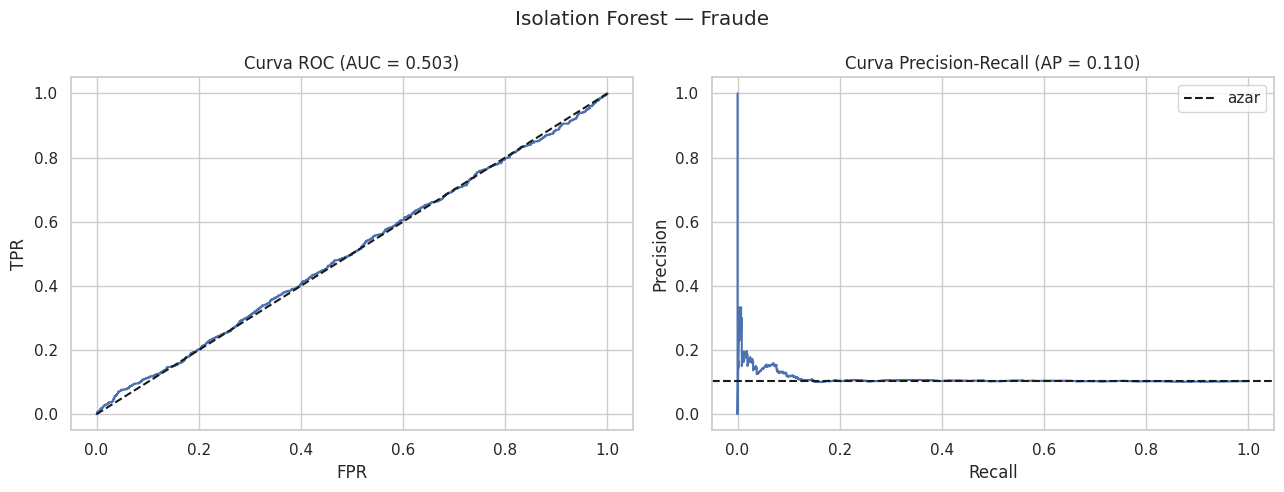

In [ ]:
tasa_fraude = y_fraud.mean()
iso_fraud = IsolationForest(n_estimators=300, max_samples='auto',
                            contamination=tasa_fraude, random_state=RNG).fit(X_fraud)

scores_fraud = -iso_fraud.score_samples(X_fraud)        # mayor = más anómalo
pred_fraud = (iso_fraud.predict(X_fraud) == -1).astype(int)

evaluar_anomalias(y_fraud, scores_fraud, pred_fraud, 'Isolation Forest — Fraude')

Es esperable un rendimiento **modesto** (ROC-AUC en torno a 0.5–0.65 y PR-AUC algo por encima de la línea base de azar). El motivo es conceptual: aquí el fraude **no es un *outlier* puro**, sino una **mezcla probabilística** de señales que también aparecen en transacciones legítimas. Isolation Forest detecta lo *raro*, no necesariamente lo *fraudulento*. Aun así, la puntuación **ordena** las transacciones por rareza, lo que sirve como **primer filtro** para priorizar revisiones. Visualizamos la separación con PCA.

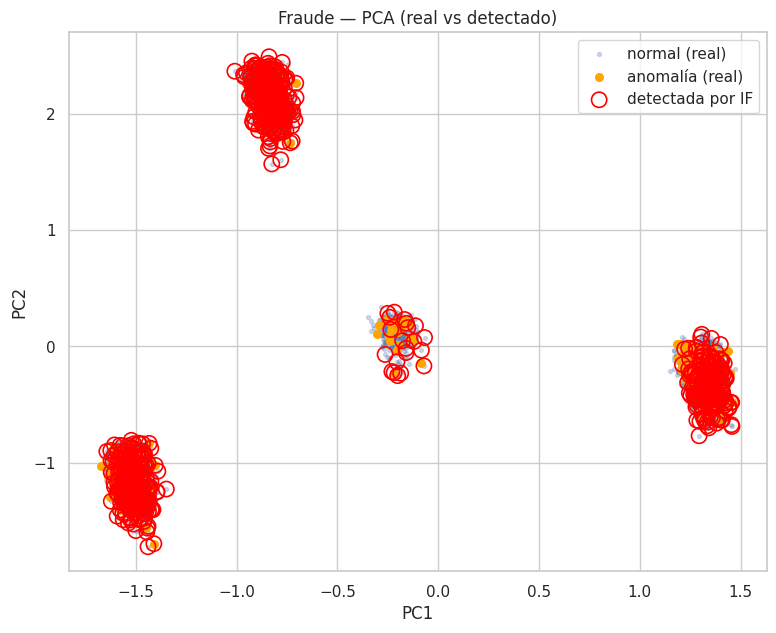

In [ ]:
viz_pca(X_fraud, y_fraud.values, pred_fraud, 'Fraude — PCA (real vs detectado)')

**¿Qué hace "raras" a las transacciones marcadas?** Comparamos el valor medio (estandarizado) de cada variable entre las transacciones señaladas y el resto.

In [ ]:
flag = pred_fraud == 1
dif = (X_imp[flag].mean() - X_imp[~flag].mean()) / X_imp.std()
dif.reindex(dif.abs().sort_values(ascending=False).index).head(8)

,0
is_first_transaction,1.256061
is_weekend,1.169492
prev_transactions,0.624286
store_type,0.527650
device_type_2.0,0.517943
device_type_0.0,-0.502776
distance_from_home,0.417402
hour_of_day,-0.176546


Las variables con mayor diferencia (importe de la transacción, *velocity_score*, distancia al domicilio, primera compra…) son las que **empujan** a una transacción hacia la zona anómala, coherente con la lógica del fraude descrita en el dataset. Esto da una lectura **interpretable** de por qué el modelo señala cada caso.

> **Comparación honesta:** los estudios de referencia de este dataset alcanzan mejores resultados con modelos **supervisados** (Random Forest, XGBoost) combinados con **SMOTE** para el desequilibrio, porque sí usan la etiqueta. Isolation Forest es la opción cuando **no hay etiquetas** o se quiere un **cribado rápido** previo.



## <font color="steelblue">5.2. Caso 2 — Predicción de quiebra empresarial</font>

Dataset del *Taiwan Economic Journal* (1999–2009): **6.819 empresas** descritas por **95 ratios financieros** y la etiqueta `Bankrupt?`. Aquí el reto es la **alta dimensión** y un desequilibrio aún mayor (~3 % de quiebras): el escenario donde Isolation Forest, al no depender de distancias ni de la dimensionalidad, suele rendir bien.

**Demasiados marcados: ordenar y revisar el top-K.** Como fijamos `contamination` ≈ tasa de fraude (~10 %), el modelo marca **por construcción** ~700 transacciones: inabordable para un equipo de revisión. La solución es la de 4.9: **ordenar por puntuación** y revisar solo la cabeza. El panorama y la **curva de ganancia** cuantifican cuántos fraudes reales se capturan según el esfuerzo de revisión.

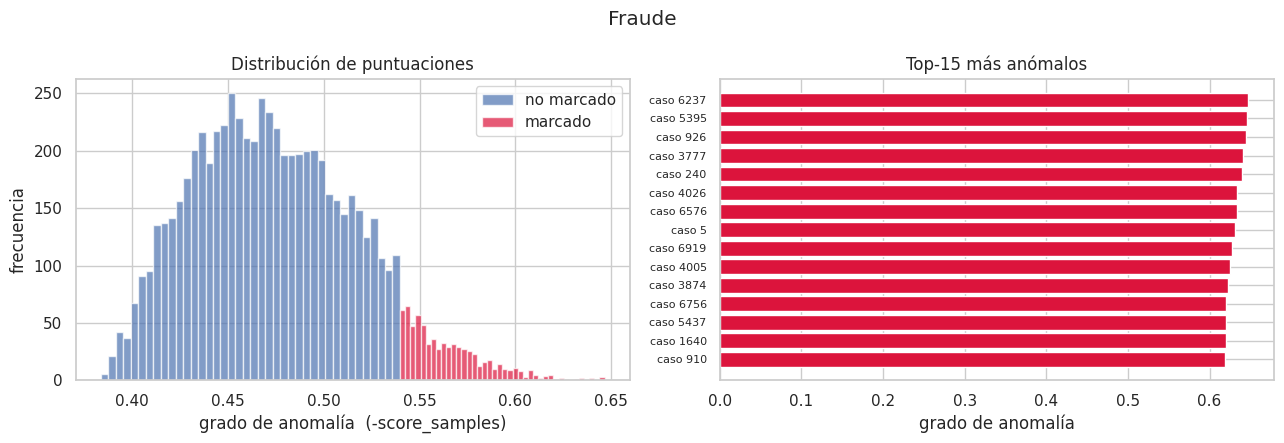

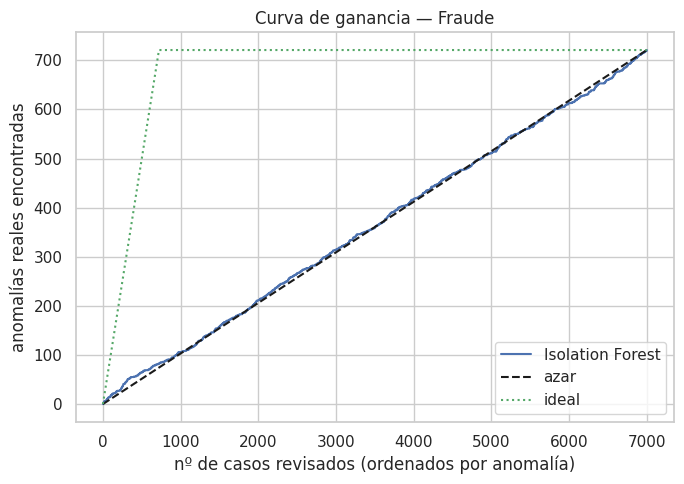

K -> (fraudes encontrados, precisión@K):
  top-100: 17 de 721   precisión=0.17
  top-300: 45 de 721   precisión=0.15
  top-500: 64 de 721   precisión=0.128
  top-700: 81 de 721   precisión=0.116


In [ ]:
top_fraude = panorama_anomalias(scores_fraud, pred_fraud, k=15, nombre='Fraude')
tabla_fraude = curva_ganancia(y_fraud.values, scores_fraud, nombre='Fraude',
                              ks=(100, 300, 500, 700))
print('K -> (fraudes encontrados, precisión@K):')
for K, v in tabla_fraude.items(): print(f'  top-{K}: {v[0]} de {int(y_fraud.sum())}   precisión={v[1]}')

**Abrir un caso concreto.** Con SHAP (que soporta el IF del fraude) y el perfil estandarizado vemos **por qué** la transacción más anómala se aísla: qué variables (importe, *velocity_score*, distancia al domicilio, primera compra…) acortan su camino.

Fraude — transacción más anómala | caso 6237: camino E[h]=6.44 (base 11.19)


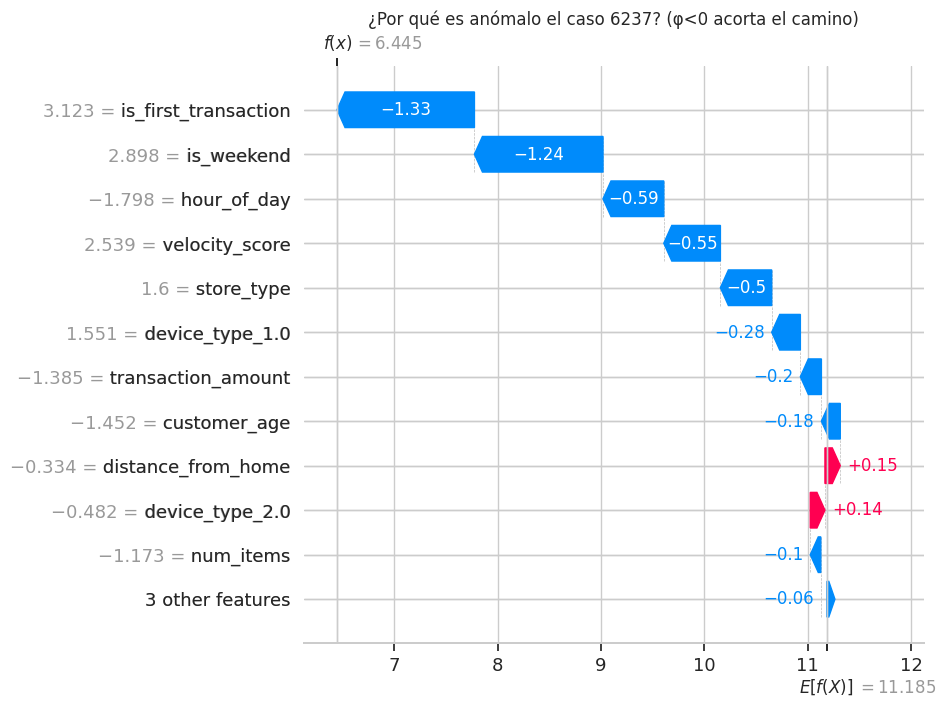

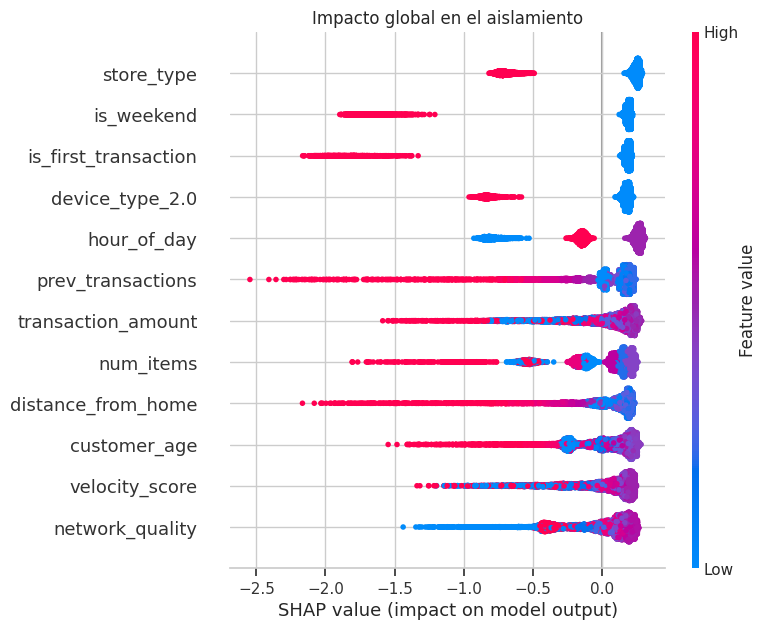

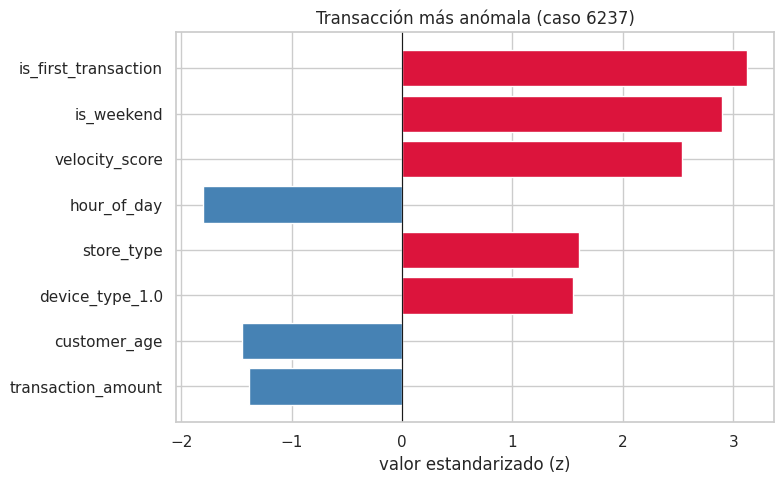

In [ ]:
i_fraude = int(np.argsort(scores_fraud)[::-1][0])     # transacción más anómala
nombres_fraude = list(X_imp.columns)
_ = explicar_anomalia_shap(iso_fraud, X_fraud, nombres_fraude, idx=i_fraude,
                           titulo='Fraude — transacción más anómala')
_ = perfil_caso(X_fraud, i_fraude, nombres_fraude, titulo=f'Transacción más anómala (caso {i_fraude})')

La curva de ganancia muestra que con una revisión acotada (la cabeza del *ranking*) se recupera una parte apreciable del fraude sin revisar las ~700 marcadas; el resto del *ranking* aporta cada vez menos. El *waterfall* y el perfil explican cada transacción señalada en términos de sus variables, que es lo que un analista necesita para decidir.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)
bank = pd.read_csv(os.path.join(path, archivos[0]))
bank.columns = bank.columns.str.strip()        # los nombres traen espacios al inicio
bank.head()

print('Dimensiones:', bank.shape)
print('\nDistribución de Bankrupt?:')
print(bank['Bankrupt?'].value_counts(normalize=True).round(4))
print('\n¿Valores faltantes?', int(bank.isna().sum().sum()))

100%|██████████| 4.63M/4.63M [00:00<00:00, 153MB/s]

Extracting files...
Archivos disponibles: ['data.csv']


Dimensiones: (6819, 96)

Distribución de Bankrupt?:
Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64

¿Valores faltantes? 0


**Preprocesado.** Todas las predictoras son numéricas y no hay nulos; solo separamos la etiqueta y **estandarizamos** (imprescindible: los 95 ratios están en escalas muy distintas).

Matriz final: (6819, 95)
===== Isolation Forest — Quiebra =====
Matriz de confusión [filas=real, cols=predicho]:
[[6414  185]
 [ 185   35]]
              precision    recall  f1-score   support

      normal      0.972     0.972     0.972      6599
    anomalía      0.159     0.159     0.159       220

    accuracy                          0.946      6819
   macro avg      0.566     0.566     0.566      6819
weighted avg      0.946     0.946     0.946      6819

ROC-AUC = 0.775   |   PR-AUC = 0.133   (línea base de azar = 0.032)


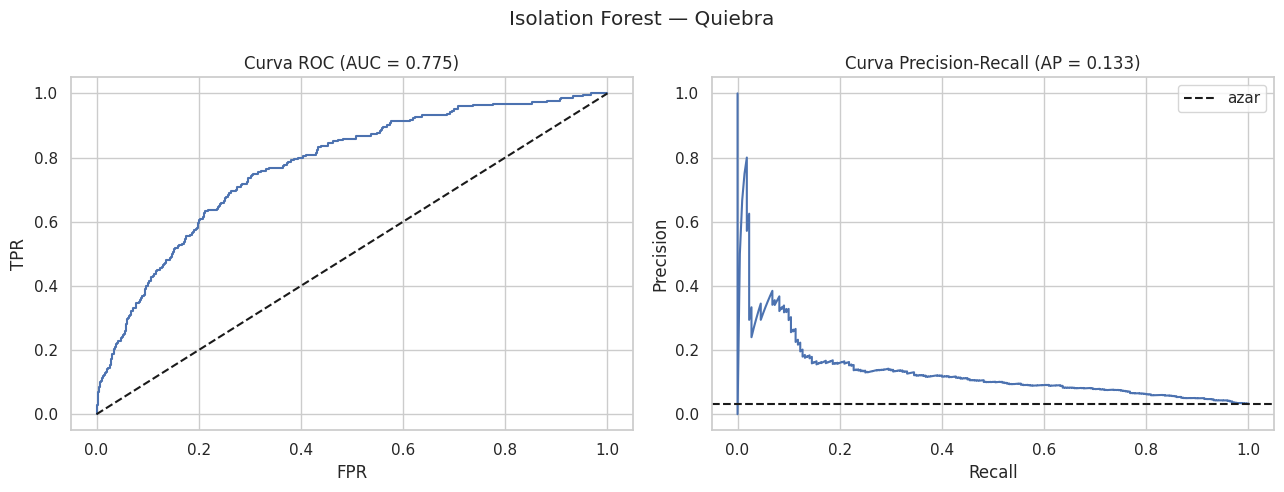

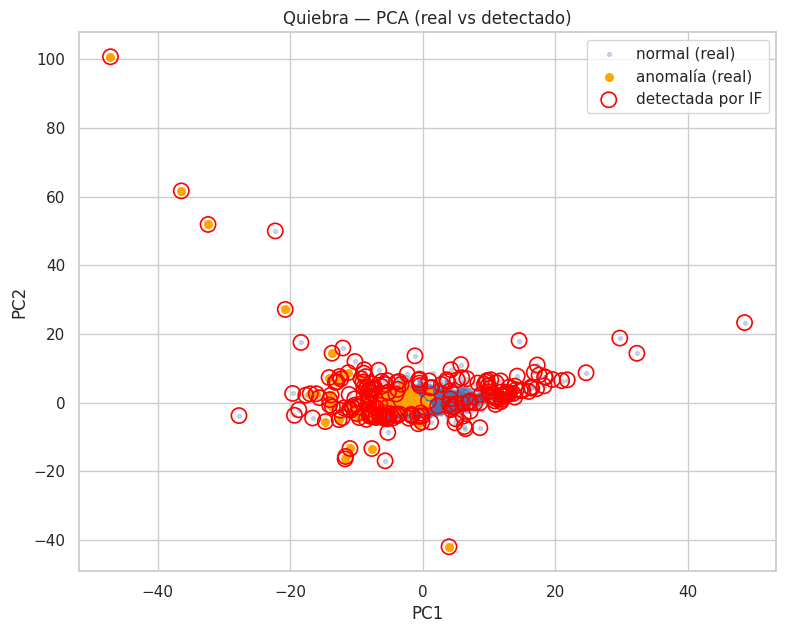

In [ ]:
y_bank = bank['Bankrupt?'].astype(int)
X_bank_raw = bank.drop(columns='Bankrupt?')
X_bank = StandardScaler().fit_transform(X_bank_raw)
print('Matriz final:', X_bank.shape)

tasa_quiebra = y_bank.mean()
iso_bank = IsolationForest(n_estimators=300, max_samples='auto',
                           contamination=tasa_quiebra, random_state=RNG).fit(X_bank)

scores_bank = -iso_bank.score_samples(X_bank)
pred_bank = (iso_bank.predict(X_bank) == -1).astype(int)

evaluar_anomalias(y_bank, scores_bank, pred_bank, 'Isolation Forest — Quiebra')

viz_pca(X_bank, y_bank.values, pred_bank, 'Quiebra — PCA (real vs detectado)')

En este caso el ROC-AUC suele ser **claramente superior al azar** (en torno a 0.8–0.9): las empresas en quiebra tienen perfiles financieros genuinamente **atípicos** (alto endeudamiento, fondo de maniobra negativo, rentabilidad muy baja), justo lo que Isolation Forest detecta bien. La PR-AUC, aunque más baja por el fuerte desequilibrio, queda muy por encima de la línea base (~0.03).

**Conexión con el Z-score de Altman.** El modelo clásico de Altman (1968) combina **cinco ratios** con pesos fijos para puntuar el riesgo de quiebra; cuatro de ellos están en este dataset (fondo de maniobra/activo, beneficios retenidos/activo, EBIT/activo, ventas/activo). Isolation Forest puede verse como una alternativa **no paramétrica y multivariante**: en vez de pesos fijos sobre 5 ratios, explota **los 95** de forma automática para encontrar los perfiles atípicos, sin asumir una fórmula lineal.

> Igual que en el fraude, un modelo **supervisado** con la etiqueta (RF/XGBoost) batiría a IF en capacidad predictiva; el valor de Isolation Forest es funcionar **sin etiquetas** y como **cribado** rápido y escalable.

**Mismas herramientas en quiebra.** Aquí `contamination` ≈ 3 % marca ~205 empresas. Con 95 ratios, el *waterfall*/*beeswarm* de SHAP resaltan automáticamente los más influyentes; mostramos también el perfil de la empresa más atípica y la curva de ganancia frente a la etiqueta real.

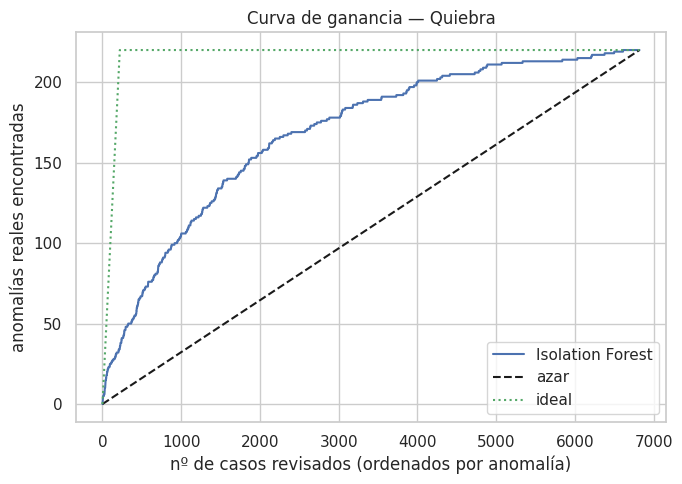

K -> (quiebras encontradas, precisión@K):
  top-50: 18 de 220   precisión=0.36
  top-100: 25 de 220   precisión=0.25
  top-200: 32 de 220   precisión=0.16
  top-400: 54 de 220   precisión=0.135
Quiebra — empresa más anómala | caso 3695: camino E[h]=7.30 (base 14.44)


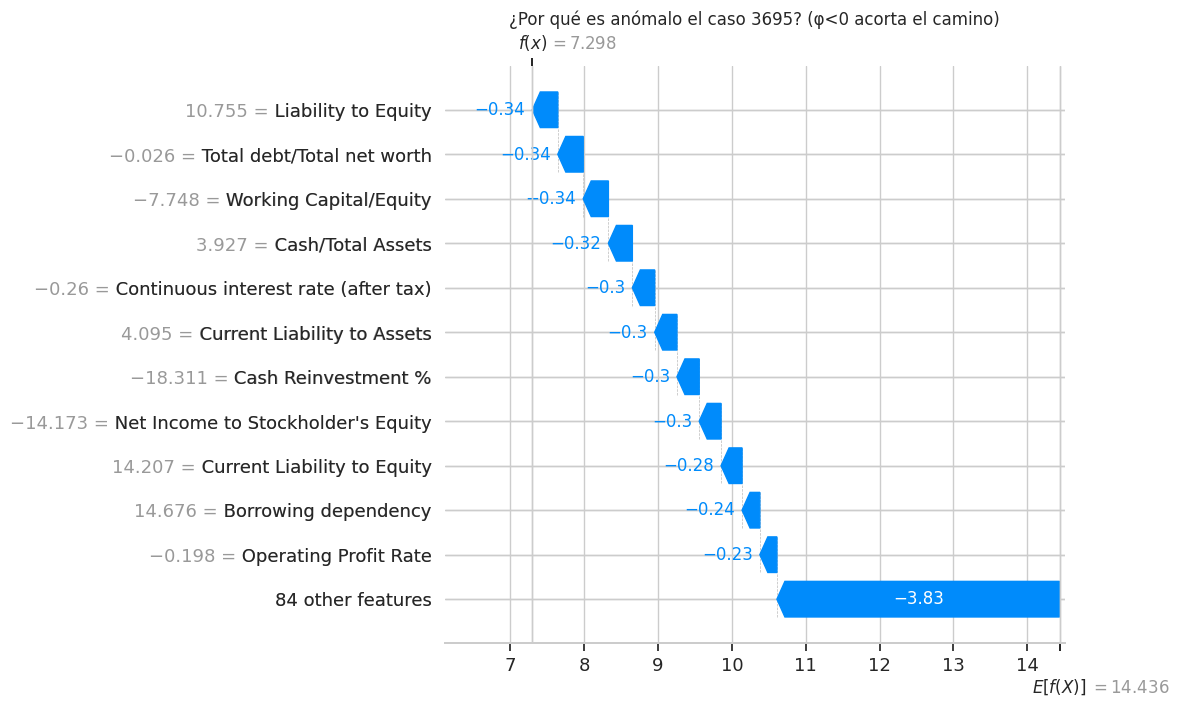

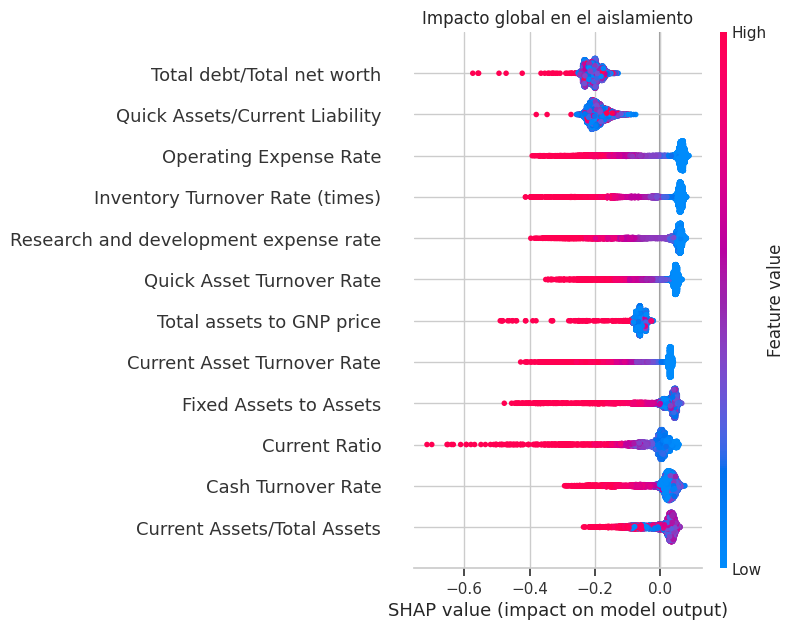

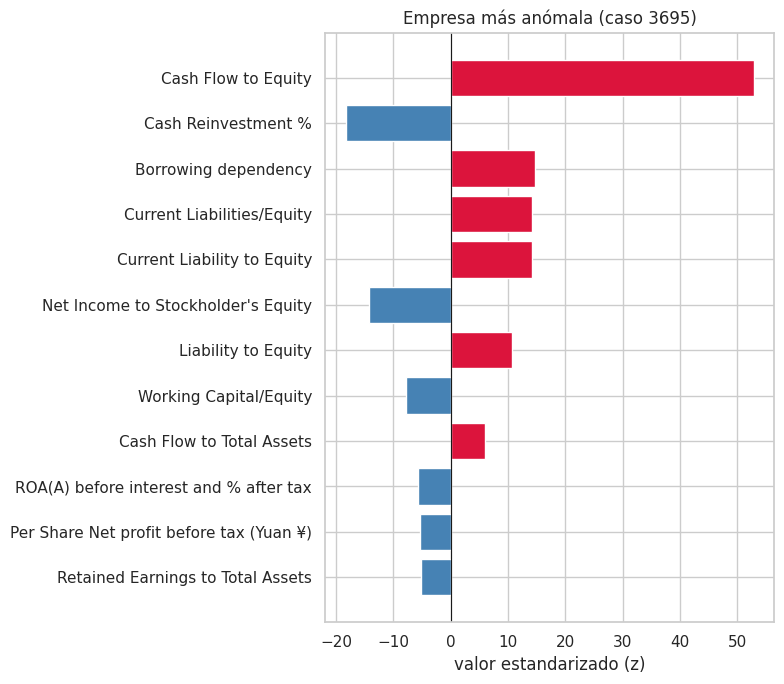

In [ ]:
tabla_quiebra = curva_ganancia(y_bank.values, scores_bank, nombre='Quiebra',
                               ks=(50, 100, 200, 400))
print('K -> (quiebras encontradas, precisión@K):')
for K, v in tabla_quiebra.items(): print(f'  top-{K}: {v[0]} de {int(y_bank.sum())}   precisión={v[1]}')

i_bank = int(np.argsort(scores_bank)[::-1][0])       # empresa más anómala
nombres_bank = list(X_bank_raw.columns)
_ = explicar_anomalia_shap(iso_bank, X_bank, nombres_bank, idx=i_bank, max_display=12,
                           titulo='Quiebra — empresa más anómala')
_ = perfil_caso(X_bank, i_bank, nombres_bank, k=12, titulo=f'Empresa más anómala (caso {i_bank})')

El perfil y SHAP suelen destacar ratios de **endeudamiento**, **rentabilidad** y **liquidez** como los que aíslan a las empresas en quiebra, en línea con la lógica financiera (y con el Z-score de Altman). De nuevo, la curva de ganancia justifica revisar un **top-K** en lugar de las ~205 marcadas.

## <font color="steelblue">5.3. Buenas prácticas y elección del umbral</font>

* **Elige las métricas correctas:** con desequilibrio fuerte, mira **recall** de la clase rara y **PR-AUC**, no la *accuracy*.
* **Separa puntuación y umbral:** entrena IF, usa `-score_samples` como grado de anomalía continuo y elige el umbral según el **coste del negocio** (cuántos casos puede revisar un analista) usando la **curva precision-recall**, en lugar de fijar `contamination` a ciegas.
* **No supervisado ≠ inútil con etiquetas:** si tienes etiquetas fiables, un modelo supervisado (con SMOTE/`class_weight`) suele ganar. Reserva Isolation Forest para cuando **no hay etiquetas**, para **cribado previo**, o para datos **muy grandes/alta dimensión** donde otros métodos no escalan.
* **¿Cuántos marcar?** No te ciñas al número que impone `contamination`: ordena por `-score_samples` y revisa el **top-K** que tu equipo pueda atender, guiándote por la **curva de ganancia** (§4.9) y un objetivo de **precisión**. Marcar la tasa base completa (cientos de casos) suele ser inabordable e innecesario.
* **Interpreta los marcados:** abre cada caso con su **perfil estandarizado** y con **SHAP** (§4.9) —que soporta `IsolationForest`— para saber **qué variables** lo aíslan; comparar contra el resto (como en el fraude) aporta explicabilidad.

El mismo *pipeline* (cargar → imputar/codificar → escalar → `IsolationForest` → evaluar con `-score_samples`) se aplica igual a otros problemas clásicos como el **fraude con tarjeta de crédito** o la **detección de intrusiones (KDD Cup 99)**.

# <font color="steelblue">6. Tabla resumen y guía de elección</font>

| Detector | Principio | Escala a datos grandes | Anomalías locales | Asume distribución |
|---|---|:---:|:---:|:---:|
| **Isolation Forest** | Aislamiento (ensemble de árboles) | ✅ muy bien | ⚠️ regular | No |
| **Extended IF** | Aislamiento con cortes oblicuos | ✅ muy bien | ⚠️ regular | No |
| **LOF** | Densidad local | ⚠️ regular | ✅ bien | No |
| **One-Class SVM** | Frontera (kernel) | ❌ costoso | ⚠️ según kernel | No |
| **Elliptic Envelope** | Gaussiana robusta | ✅ bien | ❌ no | Sí (gaussiana) |

**Guía rápida.** Para datos **grandes y/o de alta dimensión** sin suposiciones → **Isolation Forest** (como en el caso de quiebra). Si importan las **anomalías locales** y el dataset es manejable → **LOF**. Si los datos son aproximadamente **gaussianos** → **Elliptic Envelope**. Si se busca una **frontera flexible** en datos pequeños → **One-Class SVM**. En todos, `contamination`/`nu` solo fija el umbral: conviene calibrarlo y **revisar las observaciones marcadas**.

Para **detección de novedades** (entrenar con datos limpios) usa `LOF(novelty=True)` o un IF/One-Class SVM ajustado solo a datos normales (sección 4.6). Para anomalías **contextuales** y **colectivas**, la clave no es el detector sino la **ingeniería de variables**: añadir el contexto (4.7) o agregar por ventanas (4.8).





# <font color="steelblue">7. Referencias y enlaces</font>

**Artículos**
* Liu, F. T., Ting, K. M. & Zhou, Z.-H. (2008). *Isolation Forest*. ICDM. *(artículo original).*
* Liu, F. T., Ting, K. M. & Zhou, Z.-H. (2012). *Isolation-based anomaly detection*. ACM TKDD.
* Hariri, Kind & Brunner (2021). *Extended Isolation Forest*. IEEE TKDE.
* Breunig et al. (2000). *LOF: Identifying Density-Based Local Outliers*. SIGMOD.
* Altman, E. (1968). *Financial ratios, discriminant analysis and the prediction of corporate bankruptcy* (**Z-score**).

**Datasets**
* Waddah, A. (2024). *Fraud Detection*. Kaggle: `waddahali/fraud-detection`.
* Soriano, F. — *Company Bankruptcy Prediction* (Taiwan Economic Journal). Kaggle: `fedesoriano/company-bankruptcy-prediction` (UCI id=572).

**Enlaces**
* scikit-learn — *Novelty and Outlier Detection*: https://scikit-learn.org/stable/modules/outlier_detection.html
* scikit-learn — `IsolationForest` y *Comparing anomaly detection algorithms*.